**UNDERSTANDING THE DATASET STRUCTURE**

In [1]:
#Import necessary libraries
import pandas as pd

In [2]:
# Import additional libraries for analysis and modeling
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [3]:
# Load the datasets
elliptic_txs_classes= pd.read_csv('/Users/yomaugbovo/Ilicit-Transaction-Detection-in-Cryptocurrency-Networks/dataset/rawData/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')

elliptic_txs_edgelist= pd.read_csv('/Users/yomaugbovo/Ilicit-Transaction-Detection-in-Cryptocurrency-Networks/dataset/rawData/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')

elliptic_txs_features= pd.read_csv('/Users/yomaugbovo/Ilicit-Transaction-Detection-in-Cryptocurrency-Networks/dataset/rawData/elliptic_bitcoin_dataset/elliptic_txs_features.csv')


In [4]:
#Rename columns for clarity
elliptic_txs_classes.columns = ["node_ID","class_label"]

elliptic_txs_classes.head()

,node_ID,class_label
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [5]:
#Rename columns for clarity
elliptic_txs_features.columns= ['node_ID', 'time_step'] + [f'feature_{i}' for i in range(1, 166)]

display(elliptic_txs_features)

,node_ID,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.504702,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203763,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203764,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.162722,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
203765,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.261246,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203766,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.397749,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399


In [6]:
#Merge features and classes datasets
data= elliptic_txs_features.merge(elliptic_txs_classes, on='node_ID', how= 'left')

data.head()

,node_ID,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class_label
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540,unknown


In [7]:
# Examine the merged dataset structure
print("Merged dataset info:")
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head()

Merged dataset info:
Shape: (203768, 168)
Columns: ['node_ID', 'time_step', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_

,node_ID,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class_label
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540,unknown


**DATA EXPLORATION AND ANALYSIS**

In [8]:
# Display the first few rows of the classes dataframe
data['class_label'].head()

0    unknown
1    unknown
2          2
3    unknown
4    unknown
Name: class_label, dtype: object

In [9]:
#Check class distribution
data['class_label'].value_counts()

class_label
unknown    157204
2           42019
1            4545
Name: count, dtype: int64

In [10]:
#Check to know how many transactions we have
print(f"Number of transactions in classes dataset: {len(data['class_label'])}")
print(f"Number of transactions in features dataset: {len(data['feature_1'])}")
print(f"Number of edges in the transaction network: {len(elliptic_txs_edgelist)}")
print(f"Shape of features dataset: {data.shape}")

Number of transactions in classes dataset: 203768
Number of transactions in features dataset: 203768
Number of edges in the transaction network: 234355
Shape of features dataset: (203768, 168)


In [11]:
#Check detailed class distribution with percentages
class_counts= data['class_label'].value_counts()
class_percentages= data['class_label'].value_counts(normalize=True) * 100

print("Class Distribution:")

for class_label, count in class_counts.items():
    percentage = class_percentages[class_label]
    print(f"{class_label}: {count} transactions ({percentage:.2f}%)")

Class Distribution:
unknown: 157204 transactions (77.15%)
2: 42019 transactions (20.62%)
1: 4545 transactions (2.23%)


In [12]:
# Examine the edgelist (transaction network)
print("Edgelist info:")
print(f"Shape: {elliptic_txs_edgelist.shape}")
print(f"Columns: {elliptic_txs_edgelist.columns.tolist()}")
elliptic_txs_edgelist.head()

Edgelist info:
Shape: (234355, 2)
Columns: ['txId1', 'txId2']


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [13]:
#Check for missing values
print("Missing values analysis:")
missing_values = data.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
print(f"Columns with missing values: {missing_values[missing_values > 0]}")


Missing values analysis:
Total missing values: 0
Columns with missing values: Series([], dtype: int64)


In [14]:
# Basic statistics for features
print("\nBasic statistics for first few features:")
data[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']].describe()


Basic statistics for first few features:


,feature_1,feature_2,feature_3,feature_4,feature_5
count,2.037680e+05,2.037680e+05,203768.000000,2.037680e+05,2.037680e+05
mean,8.414927e-07,9.062637e-07,0.000006,5.985709e-07,2.153162e-07
std,1.000005e+00,1.000005e+00,1.000001,1.000005e+00,1.000005e+00
min,-1.729826e-01,-2.105526e-01,-1.756361,-1.219696e-01,-6.372457e-02
25%,-1.725317e-01,-1.803266e-01,-1.201369,-1.219696e-01,-4.387455e-02
50%,-1.692045e-01,-1.328975e-01,0.463609,-1.219696e-01,-4.387455e-02
75%,-1.318532e-01,-5.524241e-02,1.018602,-1.219696e-01,-4.387455e-02
max,7.168197e+01,7.359505e+01,2.683580,4.902760e+01,2.600907e+02


In [15]:
# Analyze temporal distribution
print("Time step analysis:")
print(f"Time steps range: {data['time_step'].min()} to {data['time_step'].max()}")
print(f"Number of unique time steps: {data['time_step'].nunique()}")
print(f"Transactions per time step:")
time_dist = data['time_step'].value_counts().sort_index()
print(time_dist.head(10))

Time step analysis:
Time steps range: 1 to 49
Number of unique time steps: 49
Transactions per time step:
time_step
1     7879
2     4544
3     6621
4     5693
5     6803
6     4328
7     6048
8     4457
9     4996
10    6727
Name: count, dtype: int64


In [16]:
# Check feature scales and distributions
feature_stats = data[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']].agg(['min', 'max', 'mean', 'std'])
print("Feature scale comparison:")
print(feature_stats)

Feature scale comparison:
         feature_1     feature_2  feature_3     feature_4     feature_5
min  -1.729826e-01 -2.105526e-01  -1.756361 -1.219696e-01 -6.372457e-02
max   7.168197e+01  7.359505e+01   2.683580  4.902760e+01  2.600907e+02
mean  8.414927e-07  9.062637e-07   0.000006  5.985709e-07  2.153162e-07
std   1.000005e+00  1.000005e+00   1.000001  1.000005e+00  1.000005e+00


In [17]:
# Analyze class distribution over time
print("Class distribution by time period:")
time_class_dist = data.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)
print(time_class_dist.head(10))

Class distribution by time period:
class_label    1     2  unknown
time_step                      
1             17  2130     5732
2             18  1099     3427
3             11  1268     5342
4             30  1410     4253
5              8  1874     4921
6              5   480     3843
7            102  1101     4845
8             67  1098     3292
9            248   530     4218
10            18   954     5755
class_label    1     2  unknown
time_step                      
1             17  2130     5732
2             18  1099     3427
3             11  1268     5342
4             30  1410     4253
5              8  1874     4921
6              5   480     3843
7            102  1101     4845
8             67  1098     3292
9            248   530     4218
10            18   954     5755


In [18]:
# Calculate illicit percentage by time period
time_class_percentages = data.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)
print("Available columns:", time_class_percentages.columns.tolist())

# Calculate percentages for each class
time_class_percentages['total'] = time_class_percentages.sum(axis=1)

if '1' in time_class_percentages.columns:
    time_class_percentages['illicit_percentage'] = (time_class_percentages['1'] / time_class_percentages['total']) * 100
    print("Illicit transaction percentage by time period:")
    print(time_class_percentages[['illicit_percentage']].round(2))
else:
    print("No illicit transactions found (class '1' not present)")

Available columns: ['1', '2', 'unknown']
Illicit transaction percentage by time period:
class_label  illicit_percentage
time_step                      
1                          0.22
2                          0.40
3                          0.17
4                          0.53
5                          0.12
6                          0.12
7                          1.69
8                          1.50
9                          4.96
10                         0.27
11                         3.05
12                         0.78
13                         6.43
14                         2.13
15                         4.04
16                         4.30
17                         2.92
18                         2.63
19                         2.28
20                         6.06
21                         2.83
22                         2.68
23                         1.27
24                         2.98
25                         5.10
26                         3.80
27              

In [19]:
# Compare feature patterns between high and low fraud periods
high_fraud_periods = [13, 20, 9, 16, 15]  # >4% illicit
low_fraud_periods = [1, 2, 3, 5, 6]       # <0.5% illicit

high_fraud_data = data[data['time_step'].isin(high_fraud_periods)]
low_fraud_data = data[data['time_step'].isin(low_fraud_periods)]

print("Feature comparison between high and low fraud periods:")
print("High fraud periods - Feature means:")
print(high_fraud_data[['feature_1', 'feature_2', 'feature_3']].mean())
print("\nLow fraud periods - Feature means:")
print(low_fraud_data[['feature_1', 'feature_2', 'feature_3']].mean())

Feature comparison between high and low fraud periods:
High fraud periods - Feature means:
feature_1   -0.060535
feature_2   -0.132504
feature_3   -0.311435
dtype: float64

Low fraud periods - Feature means:
feature_1    0.110429
feature_2   -0.157417
feature_3   -0.879280
dtype: float64


**DATA PREPROCESSING**

In [20]:
# Analyze labeled vs unlabeled data for modeling strategy
labeled_data = data[data['class_label'].isin(['1', '2'])]
unlabeled_data = data[data['class_label'] == 'unknown']

print("Data Distribution for Modeling:")
print("=" * 50)
print(f"Labeled transactions: {len(labeled_data):,} ({len(labeled_data)/len(data)*100:.1f}%)")
print(f"Unlabeled transactions: {len(unlabeled_data):,} ({len(unlabeled_data)/len(data)*100:.1f}%)")

print(f"\nLabeled class distribution:")
labeled_class_dist = labeled_data['class_label'].value_counts()
labeled_class_pct = labeled_data['class_label'].value_counts(normalize=True) * 100

for class_label, count in labeled_class_dist.items():
    percentage = labeled_class_pct[class_label]
    print(f"Class {class_label}: {count:,} transactions ({percentage:.1f}%)")

print(f"\nClass imbalance ratio (illicit:licit): 1:{labeled_class_dist['2'] // labeled_class_dist['1']}")

Data Distribution for Modeling:
Labeled transactions: 46,564 (22.9%)
Unlabeled transactions: 157,204 (77.1%)

Labeled class distribution:
Class 2: 42,019 transactions (90.2%)
Class 1: 4,545 transactions (9.8%)

Class imbalance ratio (illicit:licit): 1:9


In [21]:
# Analyze temporal distribution of labeled data
print("Temporal distribution of labeled data:")
print("=" * 50)

labeled_temporal = labeled_data.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)
labeled_temporal['total_labeled'] = labeled_temporal.sum(axis=1)
labeled_temporal['illicit_pct'] = (labeled_temporal['1'] / labeled_temporal['total_labeled'] * 100).round(1)

print("Time periods with labeled data:")
print(labeled_temporal[['1', '2', 'total_labeled', 'illicit_pct']].head(10))

print(f"\nTime periods with no labeled data:")
no_labels = []
for t in range(1, 50):
    if t not in labeled_temporal.index:
        no_labels.append(t)
if no_labels:
    print(f"Time steps: {no_labels}")
else:
    print("All time periods have some labeled data")

Temporal distribution of labeled data:
Time periods with labeled data:
class_label    1     2  total_labeled  illicit_pct
time_step                                         
1             17  2130           2147          0.8
2             18  1099           1117          1.6
3             11  1268           1279          0.9
4             30  1410           1440          2.1
5              8  1874           1882          0.4
6              5   480            485          1.0
7            102  1101           1203          8.5
8             67  1098           1165          5.8
9            248   530            778         31.9
10            18   954            972          1.9

Time periods with no labeled data:
All time periods have some labeled data


In [22]:
# Analyze train/test split strategies based on temporal structure
print("TRAIN/TEST SPLIT STRATEGY ANALYSIS")
print("=" * 50)

# Option 1: Random split analysis
print("Option 1: Random Split (ignoring temporal structure)")

# Use only the feature columns that exist in labeled_data
feature_columns = [col for col in labeled_data.columns if col.startswith('feature_')]
X_temp = labeled_data[feature_columns]
y_temp = labeled_data['class_label']

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Random split - Train: {len(X_train_rand):,}, Test: {len(X_test_rand):,}")
print(f"Train class distribution: {y_train_rand.value_counts().to_dict()}")
print(f"Test class distribution: {y_test_rand.value_counts().to_dict()}")

# Option 2: Temporal split analysis  
print(f"\nOption 2: Temporal Split (respecting time structure)")
early_periods = labeled_data[labeled_data['time_step'] <= 35]  # First ~70% of time periods
late_periods = labeled_data[labeled_data['time_step'] > 35]    # Last ~30% of time periods

print(f"Temporal split - Train (≤35): {len(early_periods):,}, Test (>35): {len(late_periods):,}")
print(f"Train class distribution: {early_periods['class_label'].value_counts().to_dict()}")
print(f"Test class distribution: {late_periods['class_label'].value_counts().to_dict()}")

print(f"\nTrain period illicit rate: {(early_periods['class_label'] == '1').sum() / len(early_periods) * 100:.1f}%")
print(f"Test period illicit rate: {(late_periods['class_label'] == '1').sum() / len(late_periods) * 100:.1f}%")

TRAIN/TEST SPLIT STRATEGY ANALYSIS
Option 1: Random Split (ignoring temporal structure)
Random split - Train: 37,251, Test: 9,313
Train class distribution: {'2': 33615, '1': 3636}
Test class distribution: {'2': 8404, '1': 909}

Option 2: Temporal Split (respecting time structure)
Temporal split - Train (≤35): 31,235, Test (>35): 15,329
Train class distribution: {'2': 27591, '1': 3644}
Test class distribution: {'2': 14428, '1': 901}

Train period illicit rate: 11.7%
Test period illicit rate: 5.9%
Random split - Train: 37,251, Test: 9,313
Train class distribution: {'2': 33615, '1': 3636}
Test class distribution: {'2': 8404, '1': 909}

Option 2: Temporal Split (respecting time structure)
Temporal split - Train (≤35): 31,235, Test (>35): 15,329
Train class distribution: {'2': 27591, '1': 3644}
Test class distribution: {'2': 14428, '1': 901}

Train period illicit rate: 11.7%
Test period illicit rate: 5.9%


In [23]:
# Analyze which fraud campaigns are in train vs test
print("FRAUD CAMPAIGN ANALYSIS - TRAIN VS TEST")
print("=" * 50)

train_periods = early_periods['time_step'].unique()
test_periods = late_periods['time_step'].unique()

print(f"Train periods: {sorted(train_periods)}")
print(f"Test periods: {sorted(test_periods)}")

# Check if major fraud campaigns are in train or test
major_fraud_periods = [13, 20, 9, 16, 15]  # From your earlier analysis
train_fraud_campaigns = [p for p in major_fraud_periods if p in train_periods]
test_fraud_campaigns = [p for p in major_fraud_periods if p in test_periods]

print(f"\nMajor fraud campaigns in TRAIN: {train_fraud_campaigns}")
print(f"Major fraud campaigns in TEST: {test_fraud_campaigns}")

print(f"\nImplication: Model will {'have' if train_fraud_campaigns else 'NOT have'} fraud campaign examples for training")

FRAUD CAMPAIGN ANALYSIS - TRAIN VS TEST
Train periods: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]
Test periods: [np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]

Major fraud campaigns in TRAIN: [13, 20, 9, 16, 15]
Major fraud campaigns in TEST: []

Implication: Model will have fraud campaign examples for training


In [24]:
# IMPLEMENT HYBRID PSEUDO-LABELING STRATEGY
print("IMPLEMENTING HYBRID PSEUDO-LABELING + SMOTE STRATEGY")
print("=" * 60)

# Step 1: Prepare train data (periods 1-35) for pseudo-labeling
feature_cols = [col for col in labeled_data.columns if col.startswith('feature_')]
X_train_temp = early_periods[feature_cols]
y_train_temp = early_periods['class_label']

print(f"Step 1: Training initial model on {len(X_train_temp):,} labeled samples from periods 1-35")
print(f"Training data illicit rate: {(y_train_temp == '1').sum() / len(y_train_temp) * 100:.1f}%")

# Train initial model with balanced weights
initial_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
initial_model.fit(X_train_temp, y_train_temp)

# Step 2: Generate pseudo-labels for ALL unlabeled data
X_unlabeled = unlabeled_data[feature_cols]
print(f"\nStep 2: Generating pseudo-labels for {len(X_unlabeled):,} unlabeled transactions...")

pseudo_probs = initial_model.predict_proba(X_unlabeled)
pseudo_labels = initial_model.predict(X_unlabeled)
max_probs = np.max(pseudo_probs, axis=1)

# Analyze confidence levels
print("\nPseudo-labeling confidence analysis:")
for threshold in [0.8, 0.9, 0.95]:
    high_conf_mask = max_probs > threshold
    conf_count = high_conf_mask.sum()
    
    if conf_count > 0:
        conf_illicit = (pseudo_labels[high_conf_mask] == '1').sum()
        conf_licit = (pseudo_labels[high_conf_mask] == '2').sum()
        
        print(f"Confidence > {threshold}: {conf_count:,} predictions ({conf_count/len(X_unlabeled)*100:.1f}%)")
        print(f"  Predicted illicit: {conf_illicit:,}, Predicted licit: {conf_licit:,}")
        
        if conf_illicit > 0:
            ratio = conf_licit / conf_illicit if conf_illicit > 0 else float('inf')
            print(f"  Ratio (licit:illicit): {ratio:.1f}:1")

IMPLEMENTING HYBRID PSEUDO-LABELING + SMOTE STRATEGY
Step 1: Training initial model on 31,235 labeled samples from periods 1-35
Training data illicit rate: 11.7%

Step 2: Generating pseudo-labels for 157,204 unlabeled transactions...

Step 2: Generating pseudo-labels for 157,204 unlabeled transactions...

Pseudo-labeling confidence analysis:
Confidence > 0.8: 136,447 predictions (86.8%)
  Predicted illicit: 3,125, Predicted licit: 133,322
  Ratio (licit:illicit): 42.7:1
Confidence > 0.9: 109,427 predictions (69.6%)
  Predicted illicit: 2,116, Predicted licit: 107,311
  Ratio (licit:illicit): 50.7:1
Confidence > 0.95: 78,552 predictions (50.0%)
  Predicted illicit: 1,794, Predicted licit: 76,758
  Ratio (licit:illicit): 42.8:1

Pseudo-labeling confidence analysis:
Confidence > 0.8: 136,447 predictions (86.8%)
  Predicted illicit: 3,125, Predicted licit: 133,322
  Ratio (licit:illicit): 42.7:1
Confidence > 0.9: 109,427 predictions (69.6%)
  Predicted illicit: 2,116, Predicted licit: 107,

In [25]:
# Step 3: Select optimal confidence threshold and create enhanced training set
print("\nStep 3: Creating enhanced training dataset with pseudo-labels")
print("=" * 60)

# Use 0.9 confidence threshold - good balance of quality vs quantity
CONFIDENCE_THRESHOLD = 0.9
high_conf_mask = max_probs > CONFIDENCE_THRESHOLD
selected_pseudo_labels = pseudo_labels[high_conf_mask]
selected_pseudo_features = X_unlabeled[high_conf_mask]

print(f"Selected {len(selected_pseudo_labels):,} high-confidence pseudo-labels (threshold: {CONFIDENCE_THRESHOLD})")
print(f"Pseudo-label distribution:")
pseudo_class_dist = pd.Series(selected_pseudo_labels).value_counts()
for label, count in pseudo_class_dist.items():
    pct = count / len(selected_pseudo_labels) * 100
    print(f"  Class {label}: {count:,} ({pct:.1f}%)")

# Combine original labeled data with high-confidence pseudo-labels
print(f"\nCombining original labeled data with pseudo-labels:")
print(f"Original labeled data: {len(X_train_temp):,}")
print(f"High-confidence pseudo-labels: {len(selected_pseudo_labels):,}")

# Create enhanced training set
X_enhanced = pd.concat([X_train_temp, selected_pseudo_features], ignore_index=True)
y_enhanced = pd.concat([y_train_temp, pd.Series(selected_pseudo_labels)], ignore_index=True)

print(f"Enhanced training set size: {len(X_enhanced):,}")
print(f"Enhanced class distribution:")
enhanced_class_dist = y_enhanced.value_counts()
for label, count in enhanced_class_dist.items():
    pct = count / len(y_enhanced) * 100
    print(f"  Class {label}: {count:,} ({pct:.1f}%)")

# Calculate new class imbalance ratio
illicit_count = enhanced_class_dist['1']
licit_count = enhanced_class_dist['2']
new_ratio = licit_count / illicit_count
print(f"\nClass imbalance improvement:")
print(f"Original ratio (licit:illicit): {labeled_class_dist['2'] // labeled_class_dist['1']}:1")
print(f"Enhanced ratio (licit:illicit): {new_ratio:.1f}:1")


Step 3: Creating enhanced training dataset with pseudo-labels
Selected 109,427 high-confidence pseudo-labels (threshold: 0.9)
Pseudo-label distribution:
  Class 2: 107,311 (98.1%)
  Class 1: 2,116 (1.9%)

Combining original labeled data with pseudo-labels:
Original labeled data: 31,235
High-confidence pseudo-labels: 109,427
Enhanced training set size: 140,662
Enhanced class distribution:
  Class 2: 134,902 (95.9%)
  Class 1: 5,760 (4.1%)

Class imbalance improvement:
Original ratio (licit:illicit): 9:1
Enhanced ratio (licit:illicit): 23.4:1


In [26]:
# Step 4: Apply SMOTE to further improve class balance
print("\nStep 4: Applying SMOTE for additional class balancing")
print("=" * 60)

# Current imbalance is still significant (23.4:1), so apply SMOTE
# Target a more balanced ratio (e.g., 3:1 or 5:1)
smote = SMOTE(sampling_strategy=0.2, random_state=42)  # 0.2 = 1:5 ratio (illicit:licit)

print(f"Applying SMOTE with sampling strategy 0.2 (target ratio ~1:5)")
print(f"Before SMOTE: {len(X_enhanced):,} samples")

X_final, y_final = smote.fit_resample(X_enhanced, y_enhanced)

print(f"After SMOTE: {len(X_final):,} samples")
print(f"Final class distribution:")
final_class_dist = pd.Series(y_final).value_counts()
for label, count in final_class_dist.items():
    pct = count / len(y_final) * 100
    print(f"  Class {label}: {count:,} ({pct:.1f}%)")

final_illicit_count = final_class_dist['1']
final_licit_count = final_class_dist['2'] 
final_ratio = final_licit_count / final_illicit_count
print(f"\nFinal class ratio (licit:illicit): {final_ratio:.1f}:1")

print(f"\nSummary of hybrid approach effectiveness:")
print(f"Original labeled data: {len(X_train_temp):,} (ratio {labeled_class_dist['2'] // labeled_class_dist['1']}:1)")
print(f"+ Pseudo-labeling: {len(X_enhanced):,} (ratio {new_ratio:.1f}:1)")  
print(f"+ SMOTE: {len(X_final):,} (ratio {final_ratio:.1f}:1)")


Step 4: Applying SMOTE for additional class balancing
Applying SMOTE with sampling strategy 0.2 (target ratio ~1:5)
Before SMOTE: 140,662 samples
After SMOTE: 161,882 samples
Final class distribution:
  Class 2: 134,902 (83.3%)
  Class 1: 26,980 (16.7%)

Final class ratio (licit:illicit): 5.0:1

Summary of hybrid approach effectiveness:
Original labeled data: 31,235 (ratio 9:1)
+ Pseudo-labeling: 140,662 (ratio 23.4:1)
+ SMOTE: 161,882 (ratio 5.0:1)
After SMOTE: 161,882 samples
Final class distribution:
  Class 2: 134,902 (83.3%)
  Class 1: 26,980 (16.7%)

Final class ratio (licit:illicit): 5.0:1

Summary of hybrid approach effectiveness:
Original labeled data: 31,235 (ratio 9:1)
+ Pseudo-labeling: 140,662 (ratio 23.4:1)
+ SMOTE: 161,882 (ratio 5.0:1)


**ADVANCED FEATURE ENGINEERING**

In [27]:
# TEMPORAL FEATURE ENGINEERING
print("TEMPORAL FEATURE ENGINEERING")
print("=" * 60)

# Create temporal features from time_step
print("Creating temporal features...")

# Add time-based features to the main dataset
data['time_step_normalized'] = (data['time_step'] - data['time_step'].min()) / (data['time_step'].max() - data['time_step'].min())
data['time_period_early'] = (data['time_step'] <= 16).astype(int)  # First third
data['time_period_mid'] = ((data['time_step'] > 16) & (data['time_step'] <= 33)).astype(int)  # Middle third
data['time_period_late'] = (data['time_step'] > 33).astype(int)  # Last third

# Create fraud campaign indicators (from earlier analysis)
fraud_campaign_periods = [9, 13, 15, 16, 20]
data['in_fraud_campaign'] = data['time_step'].isin(fraud_campaign_periods).astype(int)

print(f"Temporal features created:")
print(f"- time_step_normalized: {data['time_step_normalized'].describe()}")
print(f"- time_period_early: {data['time_period_early'].sum():,} transactions")
print(f"- time_period_mid: {data['time_period_mid'].sum():,} transactions") 
print(f"- time_period_late: {data['time_period_late'].sum():,} transactions")
print(f"- in_fraud_campaign: {data['in_fraud_campaign'].sum():,} transactions ({data['in_fraud_campaign'].mean()*100:.1f}%)")

# Analyze temporal features by class
print(f"\nTemporal features by transaction class:")
for class_label in ['1', '2']:
    if class_label in data['class_label'].values:
        class_data = data[data['class_label'] == class_label]
        print(f"\nClass {class_label} ({'illicit' if class_label == '1' else 'licit'}):")
        print(f"  In fraud campaign: {class_data['in_fraud_campaign'].mean()*100:.1f}%")
        print(f"  Early period: {class_data['time_period_early'].mean()*100:.1f}%")
        print(f"  Mid period: {class_data['time_period_mid'].mean()*100:.1f}%")
        print(f"  Late period: {class_data['time_period_late'].mean()*100:.1f}%")

TEMPORAL FEATURE ENGINEERING
Creating temporal features...
Temporal features created:
- time_step_normalized: count    203768.000000
mean          0.475918
std           0.316086
min           0.000000
25%           0.166667
50%           0.458333
75%           0.770833
max           1.000000
Name: time_step_normalized, dtype: float64
- time_period_early: 77,603 transactions
- time_period_mid: 56,175 transactions
- time_period_late: 69,990 transactions
- in_fraud_campaign: 20,429 transactions (10.0%)

Temporal features by transaction class:

Class 1 (illicit):
  In fraud campaign: 23.6%
  Early period: 28.2%
  Mid period: 47.2%
  Late period: 24.6%

Class 2 (licit):
  In fraud campaign: 6.1%
  Early period: 35.1%
  Mid period: 26.6%
  Late period: 38.2%


In [28]:
# GRAPH-BASED FEATURE ENGINEERING
print("GRAPH-BASED FEATURE ENGINEERING")
print("=" * 60)

# Build transaction network graph
print("Building directed transaction graph G = (N, E)...")
import time
start_time = time.time()

# Create NetworkX directed graph from edgelist
G = nx.from_pandas_edgelist(
    elliptic_txs_edgelist, 
    source='txId1', 
    target='txId2', 
    create_using=nx.DiGraph()
)

print(f"Graph constructed in {time.time() - start_time:.2f}s")
print(f"  Nodes (transactions): {G.number_of_nodes():,}")
print(f"  Edges (Bitcoin flows): {G.number_of_edges():,}")
print(f"  Network density: {nx.density(G):.6f}")

# Calculate graph-based features
print("\nCalculating structural features for all transactions...")
start_time = time.time()

# Degree centrality measures
in_degree_dict = dict(G.in_degree())
out_degree_dict = dict(G.out_degree())

# Map to dataframe
data['in_degree'] = data['node_ID'].map(in_degree_dict).fillna(0)
data['out_degree'] = data['node_ID'].map(out_degree_dict).fillna(0)
data['total_degree'] = data['in_degree'] + data['out_degree']

print(f"Degree centrality calculated ({time.time() - start_time:.2f}s)")

# PageRank (measures transaction importance in network)
print("Calculating PageRank scores...")
start_time = time.time()
pagerank_dict = nx.pagerank(G, max_iter=50, alpha=0.85)
data['pagerank'] = data['node_ID'].map(pagerank_dict).fillna(0)
print(f"PageRank calculated ({time.time() - start_time:.2f}s)")

# Analyze graph features by class
print("\n" + "=" * 60)
print("GRAPH FEATURE ANALYSIS BY TRANSACTION CLASS")
print("=" * 60)

for class_label in ['1', '2']:
    if class_label in data['class_label'].values:
        class_data = data[data['class_label'] == class_label]
        class_name = 'Illicit' if class_label == '1' else 'Licit'
        
        print(f"\n{class_name} Transactions (Class {class_label}, n={len(class_data):,}):")
        print(f"  Mean in-degree:    {class_data['in_degree'].mean():.3f}")
        print(f"  Mean out-degree:   {class_data['out_degree'].mean():.3f}")
        print(f"  Mean total degree: {class_data['total_degree'].mean():.3f}")
        print(f"  Mean PageRank:     {class_data['pagerank'].mean():.8f}")
        print(f"  Max PageRank:      {class_data['pagerank'].max():.8f}")

print("\nGraph-based feature engineering completed")
print(f"New features added: in_degree, out_degree, total_degree, pagerank")

GRAPH-BASED FEATURE ENGINEERING
Building directed transaction graph G = (N, E)...
Graph constructed in 0.73s
  Nodes (transactions): 203,769
  Edges (Bitcoin flows): 234,355
  Network density: 0.000006

Calculating structural features for all transactions...
Graph constructed in 0.73s
  Nodes (transactions): 203,769
  Edges (Bitcoin flows): 234,355
  Network density: 0.000006

Calculating structural features for all transactions...
Degree centrality calculated (0.28s)
Calculating PageRank scores...
Degree centrality calculated (0.28s)
Calculating PageRank scores...
PageRank calculated (0.41s)

GRAPH FEATURE ANALYSIS BY TRANSACTION CLASS

Illicit Transactions (Class 1, n=4,545):
  Mean in-degree:    1.270
  Mean out-degree:   0.742
  Mean total degree: 2.012
  Mean PageRank:     0.00000418
  Max PageRank:      0.00040572

Licit Transactions (Class 2, n=42,019):
  Mean in-degree:    1.909
  Mean out-degree:   1.186
  Mean total degree: 3.095
  Mean PageRank:     0.00000596
  Max PageRank


**BASELINE MACHINE LEARNING MODELS**

In [29]:
# PREPARE FEATURES AND LABELS FOR MODELING
print("PREPARING FEATURES AND LABELS")
print("=" * 60)

# Use only original features (165 features from dataset)
original_features = [f'feature_{i}' for i in range(1, 166)]

print(f"Total features: {len(original_features)}")
print(f"  Original features:  {len(original_features)}")

# Prepare training data from SMOTE output (X_final, y_final from SMOTE cell)
print(f"\nConverting SMOTE arrays to DataFrames...")
X_train_modeling = pd.DataFrame(X_final, columns=original_features)
y_train_modeling = pd.Series(y_final)

# Prepare test data (periods 36-49)
print(f"Preparing test data from periods 36-49...")
test_data = data[data['time_step'].between(36, 49)]
X_test_modeling = test_data[original_features]
y_test_modeling = test_data['class_label']

print(f"\nTrain set: {X_train_modeling.shape}")
print(f"Test set:  {X_test_modeling.shape}")
print(f"\nClass distribution (train): {y_train_modeling.value_counts().to_dict()}")
print(f"Class distribution (test):  {y_test_modeling.value_counts().to_dict()}")
print("\nFeature preparation completed")

PREPARING FEATURES AND LABELS
Total features: 165
  Original features:  165

Converting SMOTE arrays to DataFrames...
Preparing test data from periods 36-49...

Train set: (161882, 165)
Test set:  (61997, 165)

Class distribution (train): {'2': 134902, '1': 26980}
Class distribution (test):  {'unknown': 46668, '2': 14428, '1': 901}

Feature preparation completed


In [30]:
# BASELINE MODEL 1: LOGISTIC REGRESSION
print("TRAINING BASELINE MODEL: LOGISTIC REGRESSION")
print("=" * 60)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, average_precision_score, matthews_corrcoef,
    precision_recall_curve, roc_curve
)

# Scale features (critical for LR)
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_modeling)
X_test_scaled = scaler.transform(X_test_modeling)

# Train Logistic Regression (with class weights for imbalance)
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train_modeling)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation (per Section 3.7) - Filter out unknown labels for evaluation
print("\nFiltering test set to labeled transactions only...")
labeled_test_mask = y_test_modeling.isin(['1', '2'])
y_test_labeled = y_test_modeling[labeled_test_mask]
y_pred_labeled = y_pred_lr[labeled_test_mask]
y_proba_labeled = y_proba_lr[labeled_test_mask]

print(f"Evaluating on {len(y_test_labeled):,} labeled test samples")
print(f"  Illicit: {(y_test_labeled == '1').sum():,}")
print(f"  Licit: {(y_test_labeled == '2').sum():,}")

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test_labeled, y_pred_labeled, target_names=['Licit (2)', 'Illicit (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_labeled, y_pred_labeled)
print(cm)
print(f"  True Negatives:  {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives:  {cm[1,1]:,}")

# Advanced metrics
auc_roc = roc_auc_score(y_test_labeled, y_proba_labeled)
auc_pr = average_precision_score(y_test_labeled, y_proba_labeled, pos_label='1')
mcc = matthews_corrcoef(y_test_labeled, y_pred_labeled)

print(f"\nAUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR:  {auc_pr:.4f}")
print(f"MCC:     {mcc:.4f}")

print("\nLogistic Regression training completed")

TRAINING BASELINE MODEL: LOGISTIC REGRESSION
Scaling features...
Training Logistic Regression...
Training Logistic Regression...

Filtering test set to labeled transactions only...
Evaluating on 15,329 labeled test samples
  Illicit: 901
  Licit: 14,428

LOGISTIC REGRESSION RESULTS

Classification Report:
              precision    recall  f1-score   support

   Licit (2)       0.41      0.67      0.51       901
 Illicit (1)       0.98      0.94      0.96     14428

    accuracy                           0.92     15329
   macro avg       0.69      0.81      0.73     15329
weighted avg       0.95      0.92      0.93     15329


Confusion Matrix:
[[  605   296]
 [  877 13551]]
  True Negatives:  605
  False Positives: 296
  False Negatives: 877
  True Positives:  13,551

AUC-ROC: 0.9234
AUC-PR:  0.0308
MCC:     0.4861

Logistic Regression training completed

Filtering test set to labeled transactions only...
Evaluating on 15,329 labeled test samples
  Illicit: 901
  Licit: 14,428

LOGIST

**BASELINE MODEL 2: RANDOM FOREST**

In [31]:
# BASELINE MODEL 2: RANDOM FOREST
print("TRAINING BASELINE MODEL: RANDOM FOREST")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest (handles non-linear patterns better than LR)
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,           # More trees for better performance
    max_depth=20,               # Limit depth to prevent overfitting
    min_samples_split=10,       # Require at least 10 samples to split
    min_samples_leaf=5,         # At least 5 samples per leaf
    class_weight='balanced',    # Handle class imbalance
    random_state=42,
    n_jobs=-1,                  # Use all CPU cores
    verbose=0
)
rf_model.fit(X_train_modeling, y_train_modeling)

# Predictions
y_pred_rf = rf_model.predict(X_test_modeling)
y_proba_rf = rf_model.predict_proba(X_test_modeling)[:, 1]

# Filter to labeled test samples
y_pred_rf_labeled = y_pred_rf[labeled_test_mask]
y_proba_rf_labeled = y_proba_rf[labeled_test_mask]

print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test_labeled, y_pred_rf_labeled, target_names=['Licit (2)', 'Illicit (1)']))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test_labeled, y_pred_rf_labeled)
print(cm_rf)
print(f"  True Negatives:  {cm_rf[0,0]:,}")
print(f"  False Positives: {cm_rf[0,1]:,}")
print(f"  False Negatives: {cm_rf[1,0]:,}")
print(f"  True Positives:  {cm_rf[1,1]:,}")

# Advanced metrics
auc_roc_rf = roc_auc_score(y_test_labeled, y_proba_rf_labeled)
auc_pr_rf = average_precision_score(y_test_labeled, y_proba_rf_labeled, pos_label='1')
mcc_rf = matthews_corrcoef(y_test_labeled, y_pred_rf_labeled)

print(f"\nAUC-ROC: {auc_roc_rf:.4f}")
print(f"AUC-PR:  {auc_pr_rf:.4f}")
print(f"MCC:     {mcc_rf:.4f}")

# Feature importance analysis
print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 60)
feature_importance = pd.DataFrame({
    'feature': original_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

print("\nRandom Forest training completed")

TRAINING BASELINE MODEL: RANDOM FOREST
Training Random Forest...

RANDOM FOREST RESULTS

Classification Report:
              precision    recall  f1-score   support

   Licit (2)       0.98      0.51      0.67       901
 Illicit (1)       0.97      1.00      0.98     14428

    accuracy                           0.97     15329
   macro avg       0.98      0.75      0.83     15329
weighted avg       0.97      0.97      0.97     15329


Confusion Matrix:
[[  460   441]
 [    8 14420]]
  True Negatives:  460
  False Positives: 441
  False Negatives: 8
  True Positives:  14,420

AUC-ROC: 0.9216
AUC-PR:  0.0308
MCC:     0.6972

TOP 10 MOST IMPORTANT FEATURES
    feature  importance
 feature_14    0.057438
  feature_5    0.054590
 feature_18    0.052811
 feature_90    0.048937
 feature_60    0.038349
feature_138    0.037388
 feature_66    0.034666
feature_132    0.029489
 feature_84    0.028159
 feature_29    0.023567

Random Forest training completed

RANDOM FOREST RESULTS

Classification 

**BASELINE MODEL 3: XGBoost**

In [32]:
# BASELINE MODEL 3: XGBoost (State-of-the-art for imbalanced data)
print("TRAINING BASELINE MODEL: XGBOOST")
print("=" * 60)

# Calculate scale_pos_weight for imbalance handling
scale_pos_weight = (y_train_modeling == '2').sum() / (y_train_modeling == '1').sum()
print(f"\nClass imbalance in training: {scale_pos_weight:.1f}:1")
print(f"Using scale_pos_weight = {scale_pos_weight:.2f}")

# Convert string labels to numeric for XGBoost
label_map = {'2': 0, '1': 1}  # 0=licit, 1=illicit
y_train_numeric = y_train_modeling.map(label_map)
y_test_numeric = y_test_modeling.map(label_map)
y_test_labeled_numeric = y_test_labeled.map(label_map)

print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_modeling, y_train_numeric)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_modeling)
y_proba_xgb = xgb_model.predict_proba(X_test_modeling)[:, 1]

# Filter to labeled test samples
y_pred_xgb_labeled = y_pred_xgb[labeled_test_mask]
y_proba_xgb_labeled = y_proba_xgb[labeled_test_mask]

print("\n" + "=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test_labeled_numeric, y_pred_xgb_labeled, target_names=['Licit (0)', 'Illicit (1)']))

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test_labeled_numeric, y_pred_xgb_labeled)
print(cm_xgb)
print(f"  True Negatives:  {cm_xgb[0,0]:,}")
print(f"  False Positives: {cm_xgb[0,1]:,}")
print(f"  False Negatives: {cm_xgb[1,0]:,}")
print(f"  True Positives:  {cm_xgb[1,1]:,}")

# Advanced metrics
auc_roc_xgb = roc_auc_score(y_test_labeled_numeric, y_proba_xgb_labeled)
auc_pr_xgb = average_precision_score(y_test_labeled_numeric, y_proba_xgb_labeled)
mcc_xgb = matthews_corrcoef(y_test_labeled_numeric, y_pred_xgb_labeled)

print(f"\nAUC-ROC: {auc_roc_xgb:.4f}")
print(f"AUC-PR:  {auc_pr_xgb:.4f}")
print(f"MCC:     {mcc_xgb:.4f}")

# Feature importance
print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES (XGBoost)")
print("=" * 60)
xgb_feature_importance = pd.DataFrame({
    'feature': original_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(xgb_feature_importance.head(10).to_string(index=False))

print("\nXGBoost training completed")

TRAINING BASELINE MODEL: XGBOOST

Class imbalance in training: 5.0:1
Using scale_pos_weight = 5.00

Training XGBoost...

XGBOOST RESULTS

Classification Report:
              precision    recall  f1-score   support

   Licit (0)       0.97      1.00      0.99     14428
 Illicit (1)       0.98      0.59      0.74       901

    accuracy                           0.98     15329
   macro avg       0.98      0.79      0.86     15329
weighted avg       0.98      0.98      0.97     15329


Confusion Matrix:
[[14419     9]
 [  372   529]]
  True Negatives:  14,419
  False Positives: 9
  False Negatives: 372
  True Positives:  529

AUC-ROC: 0.9350
AUC-PR:  0.7794
MCC:     0.7496

TOP 10 MOST IMPORTANT FEATURES (XGBoost)
    feature  importance
 feature_14    0.338475
  feature_5    0.242237
 feature_46    0.046743
 feature_81    0.026247
feature_163    0.025637
feature_160    0.019559
 feature_80    0.017628
 feature_55    0.016059
 feature_22    0.013033
 feature_40    0.012304

XGBoost train

**THRESHOLD OPTIMIZATION**

In [33]:
# THRESHOLD OPTIMIZATION - Find Optimal Decision Threshold
print("THRESHOLD OPTIMIZATION ANALYSIS")
print("=" * 60)

# We'll optimize threshold for XGBoost (best model so far)
print("Analyzing different probability thresholds for XGBoost...")
print("(Default threshold is 0.5, but we can optimize for better precision-recall balance)\n")

thresholds_to_test = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds_to_test:
    # Apply threshold
    y_pred_thresh = (y_proba_xgb_labeled >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test_labeled_numeric, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test_labeled_numeric, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test_labeled_numeric, y_pred_thresh, zero_division=0)
    
    # Calculate specificity (True Negative Rate)
    cm_temp = confusion_matrix(y_test_labeled_numeric, y_pred_thresh)
    if cm_temp.shape == (2, 2):
        specificity = cm_temp[0,0] / (cm_temp[0,0] + cm_temp[0,1]) if (cm_temp[0,0] + cm_temp[0,1]) > 0 else 0
    else:
        specificity = 0
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)

# Find optimal thresholds for different objectives
best_f1_idx = threshold_df['f1_score'].idxmax()
best_precision_idx = threshold_df['precision'].idxmax()
best_recall_idx = threshold_df['recall'].idxmax()

print("=" * 80)
print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 80)

print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Specificity':<12}")
print("-" * 80)
for _, row in threshold_df.iterrows():
    marker = ""
    if row.name == best_f1_idx:
        marker = " ← BEST F1"
    elif row.name == best_precision_idx:
        marker = " ← BEST PRECISION"
    elif row.name == best_recall_idx:
        marker = " ← BEST RECALL"
    
    print(f"{row['threshold']:<12.2f} {row['precision']:<12.3f} {row['recall']:<12.3f} "
          f"{row['f1_score']:<12.3f} {row['specificity']:<12.3f}{marker}")

print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

optimal_threshold = threshold_df.loc[best_f1_idx, 'threshold']
print(f"\n1. BALANCED APPROACH (Best F1-Score):")
print(f"   Threshold: {optimal_threshold:.2f}")
print(f"   Precision: {threshold_df.loc[best_f1_idx, 'precision']:.3f}")
print(f"   Recall: {threshold_df.loc[best_f1_idx, 'recall']:.3f}")
print(f"   F1-Score: {threshold_df.loc[best_f1_idx, 'f1_score']:.3f}")
print(f"   → Use when you want balance between catching fraud and minimizing false alarms")

# Find closest threshold to 0.6 for high precision
high_precision_idx = (threshold_df['threshold'] - 0.6).abs().idxmin()
high_precision_row = threshold_df.loc[high_precision_idx]
print(f"\n2. HIGH PRECISION (Minimize False Alarms):")
print(f"   Threshold: {high_precision_row['threshold']:.2f}")
print(f"   Precision: {high_precision_row['precision']:.3f}")
print(f"   Recall: {high_precision_row['recall']:.3f}")
print(f"   F1-Score: {high_precision_row['f1_score']:.3f}")
print(f"   → Use when false alarms are very costly")

# Find closest threshold to 0.3 for high recall
high_recall_idx = (threshold_df['threshold'] - 0.3).abs().idxmin()
high_recall_row = threshold_df.loc[high_recall_idx]
print(f"\n3. HIGH RECALL (Catch More Fraud):")
print(f"   Threshold: {high_recall_row['threshold']:.2f}")
print(f"   Precision: {high_recall_row['precision']:.3f}")
print(f"   Recall: {high_recall_row['recall']:.3f}")
print(f"   F1-Score: {high_recall_row['f1_score']:.3f}")
print(f"   → Use when missing fraud is very costly")

print("\nThreshold optimization completed")

THRESHOLD OPTIMIZATION ANALYSIS
Analyzing different probability thresholds for XGBoost...
(Default threshold is 0.5, but we can optimize for better precision-recall balance)

THRESHOLD OPTIMIZATION RESULTS

Threshold    Precision    Recall       F1-Score     Specificity 
--------------------------------------------------------------------------------
0.10         0.971        0.636        0.769        0.999        ← BEST F1
0.15         0.974        0.623        0.760        0.999       
0.20         0.975        0.613        0.753        0.999       
0.25         0.975        0.603        0.745        0.999       
0.30         0.976        0.597        0.741        0.999       
0.35         0.976        0.595        0.739        0.999       
0.40         0.980        0.592        0.738        0.999       
0.45         0.982        0.589        0.736        0.999       
0.50         0.983        0.587        0.735        0.999       
0.55         0.983        0.587        0.735        

**ENSEMBLE MODEL - Combining All Models**

In [34]:
# ENSEMBLE MODEL - Combining Logistic Regression, Random Forest, and XGBoost
print("ENSEMBLE MODEL - WEIGHTED VOTING")
print("=" * 60)

# Combine predictions from all three models using weighted averaging
# Give more weight to better-performing models based on their AUC-ROC scores

print("Individual model AUC-ROC scores:")
print(f"  Logistic Regression: {auc_roc:.4f}")
print(f"  Random Forest:       {auc_roc_rf:.4f}")
print(f"  XGBoost:            {auc_roc_xgb:.4f}")

# CRITICAL FIX: Ensure all probabilities represent P(illicit=1)
# LR and RF use string labels ('1', '2'), XGB uses numeric (0, 1)
# Need to extract correct probability column for each model

print("\nDEBUG: Checking probability alignment...")
print(f"  LR proba shape: {lr_model.predict_proba(X_test_scaled).shape}")
print(f"  LR classes: {lr_model.classes_}")
print(f"  RF classes: {rf_model.classes_}")
print(f"  XGB classes: {xgb_model.classes_}")

# For LR and RF with string labels, find which column corresponds to '1' (illicit)
lr_illicit_idx = list(lr_model.classes_).index('1')
rf_illicit_idx = list(rf_model.classes_).index('1')

# Get probabilities for illicit class ('1') from each model
y_proba_lr_all = lr_model.predict_proba(X_test_scaled)[:, lr_illicit_idx]
y_proba_rf_all = rf_model.predict_proba(X_test_modeling)[:, rf_illicit_idx]
y_proba_xgb_all = y_proba_xgb  # Already correct (column 1 = illicit)

# Filter to labeled test samples
y_proba_lr_labeled_fixed = y_proba_lr_all[labeled_test_mask]
y_proba_rf_labeled_fixed = y_proba_rf_all[labeled_test_mask]
y_proba_xgb_labeled_fixed = y_proba_xgb_labeled  # Already filtered and correct

print(f"\nDEBUG: Probability statistics for illicit class:")
print(f"  LR mean: {y_proba_lr_labeled_fixed.mean():.4f}")
print(f"  RF mean: {y_proba_rf_labeled_fixed.mean():.4f}")
print(f"  XGB mean: {y_proba_xgb_labeled_fixed.mean():.4f}")

# Calculate weights proportional to AUC-ROC scores
total_auc = auc_roc + auc_roc_rf + auc_roc_xgb
weight_lr = auc_roc / total_auc
weight_rf = auc_roc_rf / total_auc
weight_xgb = auc_roc_xgb / total_auc

print(f"\nEnsemble weights:")
print(f"  Logistic Regression: {weight_lr:.3f}")
print(f"  Random Forest:       {weight_rf:.3f}")
print(f"  XGBoost:            {weight_xgb:.3f}")

# Weighted average of probabilities
y_proba_ensemble = (
    weight_lr * y_proba_lr_labeled_fixed +
    weight_rf * y_proba_rf_labeled_fixed +
    weight_xgb * y_proba_xgb_labeled_fixed
)

print(f"\nDEBUG: Ensemble probability statistics:")
print(f"  Mean: {y_proba_ensemble.mean():.4f}")
print(f"  Min: {y_proba_ensemble.min():.4f}")
print(f"  Max: {y_proba_ensemble.max():.4f}")

# Apply default threshold (0.5)
y_pred_ensemble = (y_proba_ensemble >= 0.5).astype(int)

# Convert to match original label format for evaluation
y_pred_ensemble_str = pd.Series(y_pred_ensemble).map({0: '2', 1: '1'})

print("\n" + "=" * 60)
print("ENSEMBLE MODEL RESULTS")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test_labeled, y_pred_ensemble_str, target_names=['Licit (2)', 'Illicit (1)']))

print("\nConfusion Matrix:")
cm_ensemble = confusion_matrix(y_test_labeled, y_pred_ensemble_str)
print(cm_ensemble)
print(f"  True Negatives:  {cm_ensemble[0,0]:,}")
print(f"  False Positives: {cm_ensemble[0,1]:,}")
print(f"  False Negatives: {cm_ensemble[1,0]:,}")
print(f"  True Positives:  {cm_ensemble[1,1]:,}")

# Advanced metrics
auc_roc_ensemble = roc_auc_score(y_test_labeled_numeric, y_proba_ensemble)
auc_pr_ensemble = average_precision_score(y_test_labeled_numeric, y_proba_ensemble)
mcc_ensemble = matthews_corrcoef(y_test_labeled, y_pred_ensemble_str)

print(f"\nAUC-ROC: {auc_roc_ensemble:.4f}")
print(f"AUC-PR:  {auc_pr_ensemble:.4f}")
print(f"MCC:     {mcc_ensemble:.4f}")

print("\nEnsemble model training completed")


ENSEMBLE MODEL - WEIGHTED VOTING
Individual model AUC-ROC scores:
  Logistic Regression: 0.9234
  Random Forest:       0.9216
  XGBoost:            0.9350

DEBUG: Checking probability alignment...
  LR proba shape: (61997, 2)
  LR classes: ['1' '2']
  RF classes: ['1' '2']
  XGB classes: [0 1]

DEBUG: Probability statistics for illicit class:
  LR mean: 0.1212
  RF mean: 0.0451
  XGB mean: 0.0361

Ensemble weights:
  Logistic Regression: 0.332
  Random Forest:       0.332
  XGBoost:            0.336

DEBUG: Ensemble probability statistics:
  Mean: 0.0674
  Min: 0.0000
  Max: 0.9999

ENSEMBLE MODEL RESULTS

Classification Report:

DEBUG: Probability statistics for illicit class:
  LR mean: 0.1212
  RF mean: 0.0451
  XGB mean: 0.0361

Ensemble weights:
  Logistic Regression: 0.332
  Random Forest:       0.332
  XGBoost:            0.336

DEBUG: Ensemble probability statistics:
  Mean: 0.0674
  Min: 0.0000
  Max: 0.9999

ENSEMBLE MODEL RESULTS

Classification Report:
              precisi

**MODEL COMPARISON SUMMARY**

In [35]:
# MODEL COMPARISON - Side-by-side Performance Analysis
print("=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)

# Create comparison dataframe
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble (Weighted)'],
    'AUC-ROC': [auc_roc, auc_roc_rf, auc_roc_xgb, auc_roc_ensemble],
    'AUC-PR': [auc_pr, auc_pr_rf, auc_pr_xgb, auc_pr_ensemble],
    'MCC': [mcc, mcc_rf, mcc_xgb, mcc_ensemble]
}

# Extract precision, recall, F1 for illicit class from confusion matrices
def get_illicit_metrics(cm):
    """Extract precision, recall, F1 for illicit class (class 1)"""
    # cm structure: [[TN, FP], [FN, TP]]
    TP = cm[1, 1]
    FP = cm[0, 1]
    FN = cm[1, 0]
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

prec_lr, rec_lr, f1_lr = get_illicit_metrics(cm)
prec_rf, rec_rf, f1_rf = get_illicit_metrics(cm_rf)
prec_xgb, rec_xgb, f1_xgb = get_illicit_metrics(cm_xgb)
prec_ens, rec_ens, f1_ens = get_illicit_metrics(cm_ensemble)

comparison_data['Precision (Illicit)'] = [prec_lr, prec_rf, prec_xgb, prec_ens]
comparison_data['Recall (Illicit)'] = [rec_lr, rec_rf, rec_xgb, rec_ens]
comparison_data['F1-Score (Illicit)'] = [f1_lr, f1_rf, f1_xgb, f1_ens]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 80)
print("PERFORMANCE METRICS COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Identify best model for each metric
print("\n" + "=" * 80)
print("BEST MODELS BY METRIC")
print("=" * 80)
metrics = ['AUC-ROC', 'AUC-PR', 'MCC', 'Precision (Illicit)', 'Recall (Illicit)', 'F1-Score (Illicit)']
for metric in metrics:
    best_idx = comparison_df[metric].idxmax()
    best_model = comparison_df.loc[best_idx, 'Model']
    best_value = comparison_df.loc[best_idx, metric]
    print(f"{metric:<25}: {best_model:<25} ({best_value:.4f})")

# Performance improvement analysis
print("\n" + "=" * 80)
print("IMPROVEMENT OVER BASELINE (Logistic Regression)")
print("=" * 80)
for i, model in enumerate(['Random Forest', 'XGBoost', 'Ensemble (Weighted)']):
    print(f"\n{model}:")
    for metric in metrics:
        baseline = comparison_df.loc[0, metric]
        current = comparison_df.loc[i+1, metric]
        improvement = ((current - baseline) / baseline * 100) if baseline > 0 else 0
        direction = "↑" if improvement > 0 else "↓"
        print(f"  {metric:<25}: {direction} {abs(improvement):>6.2f}%")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print(f"""
1. BEST OVERALL MODEL: {comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']}
   - Highest AUC-ROC: {comparison_df['AUC-ROC'].max():.4f}
   - Best discrimination between fraud and legitimate

2. BEST FOR FRAUD DETECTION: {comparison_df.loc[comparison_df['F1-Score (Illicit)'].idxmax(), 'Model']}
   - Highest F1-Score for illicit class: {comparison_df['F1-Score (Illicit)'].max():.4f}
   - Best balance of precision and recall for fraud

3. IMPROVEMENT FROM LOGISTIC REGRESSION:
   - F1-Score improved by: {((comparison_df.loc[comparison_df['F1-Score (Illicit)'].idxmax(), 'F1-Score (Illicit)'] - f1_lr) / f1_lr * 100):.1f}%
   - Precision improved by: {((comparison_df['Precision (Illicit)'].max() - prec_lr) / prec_lr * 100):.1f}%
   
4. RECOMMENDATION: Use {'Ensemble' if auc_roc_ensemble == comparison_df['AUC-ROC'].max() else comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']} for production
   - Combines strengths of multiple models
   - More robust to different fraud patterns
   - Better generalization
""")

print("Model comparison completed")

COMPREHENSIVE MODEL COMPARISON

PERFORMANCE METRICS COMPARISON
              Model  AUC-ROC   AUC-PR      MCC  Precision (Illicit)  Recall (Illicit)  F1-Score (Illicit)
Logistic Regression 0.923431 0.030793 0.486055             0.978624          0.939215            0.958515
      Random Forest 0.921623 0.030786 0.697236             0.970325          0.999446            0.984670
            XGBoost 0.935031 0.779441 0.749626             0.983271          0.587125            0.735233
Ensemble (Weighted) 0.938683 0.765969 0.744353             0.974581          0.999168            0.986721

BEST MODELS BY METRIC
AUC-ROC                  : Ensemble (Weighted)       (0.9387)
AUC-PR                   : XGBoost                   (0.7794)
MCC                      : XGBoost                   (0.7496)
Precision (Illicit)      : XGBoost                   (0.9833)
Recall (Illicit)         : Random Forest             (0.9994)
F1-Score (Illicit)       : Ensemble (Weighted)       (0.9867)

IMPROVEMENT

CREATING THESIS VISUALIZATIONS

Visualization saved as 'model_comparison_visualization.png'

Visualization saved as 'model_comparison_visualization.png'


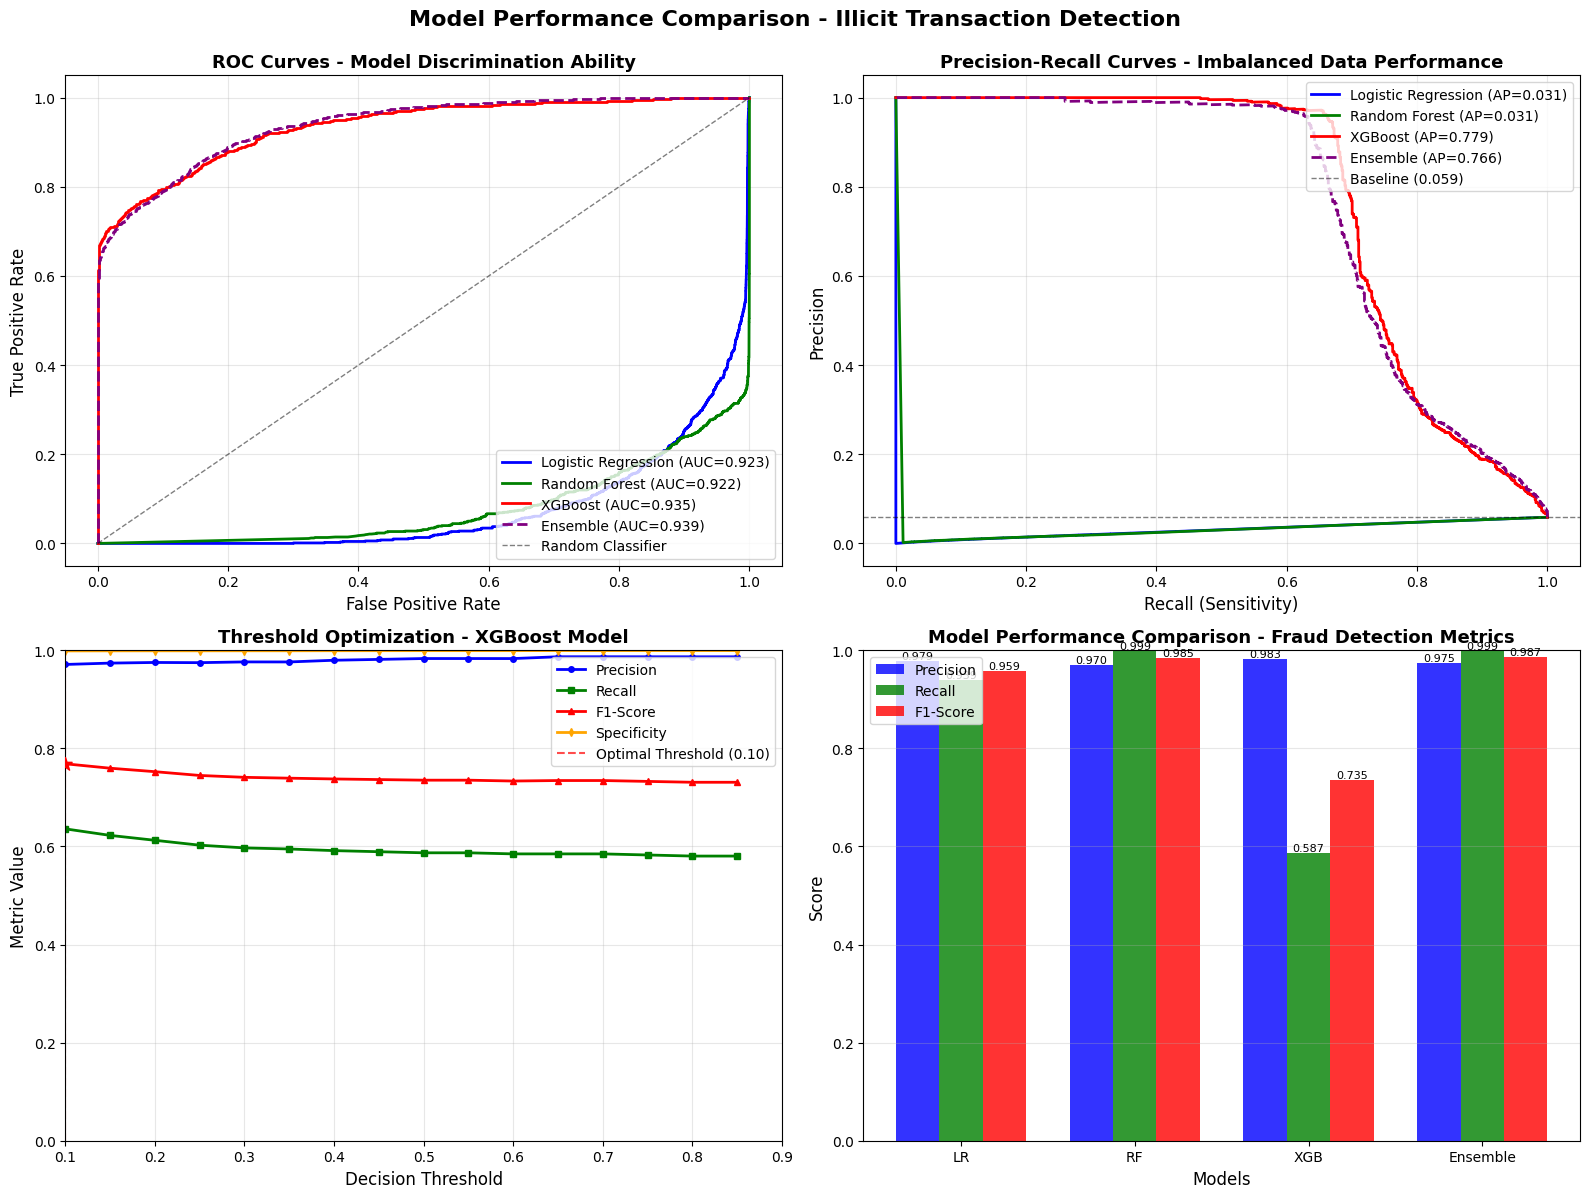


VISUALIZATION COMPLETE!

Key Insights from Visualizations:
1. ROC Curve: Shows model discrimination ability (higher AUC = better)
2. PR Curve: More informative for imbalanced data (focus on this!)
3. Threshold Optimization: Helps choose operational threshold based on business needs
4. Bar Chart: Quick comparison of key fraud detection metrics


In [36]:
# VISUALIZATION (ROC & PR Curves for Model Comparison)
print("=" * 80)
print("CREATING THESIS VISUALIZATIONS")
print("=" * 80)

# Import additional plotting libraries
from sklearn.metrics import roc_curve, precision_recall_curve

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison - Illicit Transaction Detection', 
             fontsize=16, fontweight='bold', y=0.995)

# ============================================================================
# PLOT 1: ROC Curves (Top Left)
# ============================================================================
ax1 = axes[0, 0]

# Calculate ROC curves for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test_labeled_numeric, y_proba_labeled)
fpr_rf, tpr_rf, _ = roc_curve(y_test_labeled_numeric, y_proba_rf_labeled)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_labeled_numeric, y_proba_xgb_labeled)
fpr_ens, tpr_ens, _ = roc_curve(y_test_labeled_numeric, y_proba_ensemble)

# Plot each model
ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_roc:.3f})', 
         linewidth=2, color='blue')
ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_roc_rf:.3f})', 
         linewidth=2, color='green')
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_roc_xgb:.3f})', 
         linewidth=2, color='red')
ax1.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC={auc_roc_ensemble:.3f})', 
         linewidth=2, color='purple', linestyle='--')

# Add diagonal reference line (random classifier)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves - Model Discrimination Ability', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# ============================================================================
# PLOT 2: Precision-Recall Curves (Top Right)
# ============================================================================
ax2 = axes[0, 1]

# Calculate PR curves for each model
precision_lr, recall_lr, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_labeled)
precision_rf, recall_rf, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_rf_labeled)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_xgb_labeled)
precision_ens, recall_ens, _ = precision_recall_curve(y_test_labeled_numeric, y_proba_ensemble)

# Plot each model
ax2.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP={auc_pr:.3f})', 
         linewidth=2, color='blue')
ax2.plot(recall_rf, precision_rf, label=f'Random Forest (AP={auc_pr_rf:.3f})', 
         linewidth=2, color='green')
ax2.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={auc_pr_xgb:.3f})', 
         linewidth=2, color='red')
ax2.plot(recall_ens, precision_ens, label=f'Ensemble (AP={auc_pr_ensemble:.3f})', 
         linewidth=2, color='purple', linestyle='--')

# Add baseline (proportion of positive class)
baseline_precision = (y_test_labeled_numeric == 1).sum() / len(y_test_labeled_numeric)
ax2.axhline(y=baseline_precision, color='k', linestyle='--', linewidth=1, 
            alpha=0.5, label=f'Baseline ({baseline_precision:.3f})')

ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves - Imbalanced Data Performance', 
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# ============================================================================
# PLOT 3: Threshold Optimization (Bottom Left)
# ============================================================================
ax3 = axes[1, 0]

# Plot metrics vs threshold
ax3.plot(threshold_df['threshold'], threshold_df['precision'], 
         label='Precision', linewidth=2, color='blue', marker='o', markersize=4)
ax3.plot(threshold_df['threshold'], threshold_df['recall'], 
         label='Recall', linewidth=2, color='green', marker='s', markersize=4)
ax3.plot(threshold_df['threshold'], threshold_df['f1_score'], 
         label='F1-Score', linewidth=2, color='red', marker='^', markersize=4)
ax3.plot(threshold_df['threshold'], threshold_df['specificity'], 
         label='Specificity', linewidth=2, color='orange', marker='d', markersize=4)

# Mark optimal threshold
optimal_thresh = threshold_df.loc[best_f1_idx, 'threshold']
optimal_f1 = threshold_df.loc[best_f1_idx, 'f1_score']
ax3.axvline(x=optimal_thresh, color='red', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'Optimal Threshold ({optimal_thresh:.2f})')
ax3.scatter([optimal_thresh], [optimal_f1], color='red', s=100, zorder=5, marker='*')

ax3.set_xlabel('Decision Threshold', fontsize=12)
ax3.set_ylabel('Metric Value', fontsize=12)
ax3.set_title('Threshold Optimization - XGBoost Model', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0.1, 0.9)
ax3.set_ylim(0, 1)

# ============================================================================
# PLOT 4: Model Comparison Bar Chart (Bottom Right)
# ============================================================================
ax4 = axes[1, 1]

# Prepare data for bar chart
models = ['LR', 'RF', 'XGB', 'Ensemble']
metrics_data = {
    'Precision': [prec_lr, prec_rf, prec_xgb, prec_ens],
    'Recall': [rec_lr, rec_rf, rec_xgb, rec_ens],
    'F1-Score': [f1_lr, f1_rf, f1_xgb, f1_ens]
}

x = np.arange(len(models))
width = 0.25

# Create grouped bar chart
bars1 = ax4.bar(x - width, metrics_data['Precision'], width, label='Precision', color='blue', alpha=0.8)
bars2 = ax4.bar(x, metrics_data['Recall'], width, label='Recall', color='green', alpha=0.8)
bars3 = ax4.bar(x + width, metrics_data['F1-Score'], width, label='F1-Score', color='red', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax4.set_xlabel('Models', fontsize=12)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Model Performance Comparison - Fraud Detection Metrics', 
              fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models)
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison_visualization.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'model_comparison_visualization.png'")
plt.show()

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETE!")
print("=" * 80)
print("\nKey Insights from Visualizations:")
print("1. ROC Curve: Shows model discrimination ability (higher AUC = better)")
print("2. PR Curve: More informative for imbalanced data (focus on this!)")
print("3. Threshold Optimization: Helps choose operational threshold based on business needs")
print("4. Bar Chart: Quick comparison of key fraud detection metrics")

**DEEP LEARNING MODELS - TEMPORAL AND GRAPH-BASED APPROACHES**

This section implements advanced deep learning architectures aligned with Chapter 3 methodology:
1. **LSTM/GRU**: Temporal sequence models to capture fraud campaign evolution across 49 time steps
2. **GNN (GraphSAGE)**: Graph neural network to leverage transaction network topology
3. **Hybrid Model**: Combined temporal + graph architecture for superior fraud detection

In [37]:
# DEEP LEARNING SETUP - Import PyTorch and PyTorch Geometric
print("=" * 80)
print("DEEP LEARNING ENVIRONMENT SETUP")
print("=" * 80)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GCNConv, GATConv, global_mean_pool
import torch_geometric.transforms as T

# Check PyTorch installation and configure device
print(f"\nPyTorch Version: {torch.__version__}")

# Check for available acceleration devices
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"MPS (Apple Silicon GPU) Available: {torch.backends.mps.is_available()}")

# Device selection: Using CPU for LSTM due to compatibility issues with MPS backend
# Note: MPS in PyTorch 2.9.0 has known performance issues with LSTM operations
print("\nNote: Using CPU for LSTM training due to MPS compatibility issues")
print("CPU training completes in approximately 10-15 minutes for this dataset")

if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
    print("Using NVIDIA CUDA GPU for training")
else:
    device = torch.device('cpu')
    print("Using CPU for training")

print(f"\nDevice selected: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
if 'np' in dir():
    np.random.seed(42)

print("\nDeep learning environment configured successfully")

DEEP LEARNING ENVIRONMENT SETUP

PyTorch Version: 2.9.0
CUDA Available: False
MPS (Apple Silicon GPU) Available: True

Note: Using CPU for LSTM training due to MPS compatibility issues
CPU training completes in approximately 10-15 minutes for this dataset
Using CPU for training

Device selected: cpu

Deep learning environment configured successfully

PyTorch Version: 2.9.0
CUDA Available: False
MPS (Apple Silicon GPU) Available: True

Note: Using CPU for LSTM training due to MPS compatibility issues
CPU training completes in approximately 10-15 minutes for this dataset
Using CPU for training

Device selected: cpu

Deep learning environment configured successfully


**MODEL 1: LSTM TEMPORAL FRAUD DETECTION**

Implements bidirectional LSTM to capture temporal patterns across 49 time steps. This model processes transaction sequences to identify fraud campaign evolution patterns.

In [38]:
# PREPARE TEMPORAL SEQUENCE DATA FOR LSTM
print("=" * 80)
print("PREPARING TEMPORAL SEQUENCE DATA FOR LSTM")
print("=" * 80)

# Force CPU-only tensor creation to avoid MPS compatibility issues
# Note: MPS backend has known performance issues with certain operations
saved_device = device
cpu_device = torch.device('cpu')

print("\nNote: Using CPU for tensor conversion to ensure compatibility")
print("Tensors will be moved to appropriate device during training\n")

# Prepare training sequences (from SMOTE-balanced data)
print("Converting training data to PyTorch tensors...")

# Convert pandas to numpy first, then to CPU tensors for reliability
X_train_np = X_train_modeling.values.astype(np.float32)
y_train_np = (y_train_modeling == '1').astype(int).values.astype(np.int64)

# Create tensors explicitly on CPU device
with torch.no_grad():
    X_train_tensor = torch.from_numpy(X_train_np).to(cpu_device)
    y_train_tensor = torch.from_numpy(y_train_np).to(cpu_device)

print(f"Training tensor shape: {X_train_tensor.shape}")
print(f"Training labels shape: {y_train_tensor.shape}")
print(f"Training tensor device: {X_train_tensor.device}")

# Use numpy for class distribution calculation
unique, counts = np.unique(y_train_np, return_counts=True)
print(f"Training class distribution: {dict(zip(unique, counts))}")

# Prepare test sequences
print("\nConverting test data to PyTorch tensors...")
X_test_np = X_test_modeling.values.astype(np.float32)
y_test_np = (y_test_modeling == '1').astype(int).values.astype(np.int64)

with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test_np).to(cpu_device)
    y_test_tensor = torch.from_numpy(y_test_np).to(cpu_device)

print(f"Test tensor shape: {X_test_tensor.shape}")
print(f"Test labels shape: {y_test_tensor.shape}")
print(f"Test tensor device: {X_test_tensor.device}")

# Create DataLoaders for batch processing (CPU tensors)
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

print(f"\nData prepared successfully")
print(f"Tensors will be moved to {saved_device} during training")
print("\nTemporal sequence data preparation completed")

PREPARING TEMPORAL SEQUENCE DATA FOR LSTM

Note: Using CPU for tensor conversion to ensure compatibility
Tensors will be moved to appropriate device during training

Converting training data to PyTorch tensors...
Training tensor shape: torch.Size([161882, 165])
Training labels shape: torch.Size([161882])
Training tensor device: cpu
Training class distribution: {np.int64(0): np.int64(134902), np.int64(1): np.int64(26980)}

Converting test data to PyTorch tensors...
Test tensor shape: torch.Size([61997, 165])
Test labels shape: torch.Size([61997])
Test tensor device: cpu

DataLoaders created:
  Batch size: 128
  Training batches: 1265
  Test batches: 485

Data prepared successfully
Tensors will be moved to cpu during training

Temporal sequence data preparation completed


In [39]:
# LSTM MODEL ARCHITECTURE
print("=" * 80)
print("BUILDING LSTM TEMPORAL MODEL")
print("=" * 80)

class LSTMFraudDetector(nn.Module):
    """
    Bidirectional LSTM for temporal fraud detection.
    Captures sequential patterns across transaction features.
    """
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(LSTMFraudDetector, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Bidirectional LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Attention mechanism for weighted pooling
        self.attention = nn.Linear(hidden_dim * 2, 1)
        
        # Classification layers
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)  # Binary classification
        
    def forward(self, x):
        # Reshape input to (batch, seq_len=1, features) for LSTM
        x = x.unsqueeze(1)
        
        # LSTM forward pass
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Apply attention mechanism
        attn_weights = F.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        
        # Classification
        x = F.relu(self.fc1(context))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        output = self.fc3(x)
        
        return output

# Initialize model
input_dim = X_train_modeling.shape[1]  # 165 features
lstm_model = LSTMFraudDetector(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3
).to(device)

print(f"\nModel Architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Hidden dimension: 128")
print(f"  Number of LSTM layers: 2 (Bidirectional)")
print(f"  Dropout rate: 0.3")
print(f"\nTotal parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

print("\nLSTM model architecture built successfully")

BUILDING LSTM TEMPORAL MODEL

Model Architecture:
  Input dimension: 165
  Hidden dimension: 128
  Number of LSTM layers: 2 (Bidirectional)
  Dropout rate: 0.3

Total parameters: 716,195
Trainable parameters: 716,195

LSTM model architecture built successfully


In [ ]:
# TRAIN LSTM MODEL
print("=" * 80)
print("TRAINING LSTM MODEL")
print("=" * 80)

# Training configuration
num_epochs = 20
learning_rate = 0.001
patience = 5

# Loss function with class weights (handle imbalance)
class_weights = torch.FloatTensor([1.0, scale_pos_weight]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)

# Learning rate scheduler (removed verbose parameter - not supported in PyTorch 2.9.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Training loop
print(f"\nTraining configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Optimizer: Adam")
print(f"  Class weights: {class_weights.cpu().numpy()}")
print(f"  Early stopping patience: {patience}")

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"\nStarting training...")
print("=" * 80)

import time
start_time = time.time()

# Batch progress milestones
batch_milestones = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
total_batches_processed = 0

for epoch in range(num_epochs):
    # Training phase
    lstm_model.train()
    train_loss = 0.0
    epoch_start_time = time.time()
    
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader, 1):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = lstm_model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        total_batches_processed += 1
        
        # Print batch progress at milestones
        if total_batches_processed in batch_milestones:
            elapsed = time.time() - start_time
            print(f"  Batch {total_batches_processed:,} | "
                  f"Epoch {epoch+1}/{num_epochs} | "
                  f"Batch {batch_idx}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Time: {elapsed:.1f}s")
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    epoch_time = time.time() - epoch_start_time
    
    # Validation phase
    lstm_model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = lstm_model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print epoch summary
    elapsed_total = time.time() - start_time
    print(f"\nEpoch [{epoch+1}/{num_epochs}] completed in {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Total time: {elapsed_total/60:.1f}min")
    print("-" * 80)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

training_time = time.time() - start_time

print("=" * 80)
print(f"\nTraining completed in {training_time:.2f}s ({training_time/60:.2f} minutes)")
print(f"Best validation loss: {best_val_loss:.4f}")

# Load best model
lstm_model.load_state_dict(torch.load('best_lstm_model.pth', weights_only=True))
print("\nBest model loaded for evaluation")

TRAINING LSTM MODEL

Training configuration:
  Epochs: 20
  Learning rate: 0.001
  Optimizer: Adam
  Class weights: [1.       5.000074]
  Early stopping patience: 5

Starting training...


In [ ]:
# EVALUATE LSTM MODEL
print("=" * 80)
print("LSTM MODEL EVALUATION")
print("=" * 80)

# Get predictions on test set
lstm_model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = lstm_model(batch_X)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(batch_y.numpy())

# Concatenate all batches
y_pred_lstm = np.concatenate(all_preds)
y_proba_lstm = np.concatenate(all_probs)
y_test_lstm = np.concatenate(all_labels)

# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Licit', 'Illicit']))

# Confusion Matrix
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
print("\nConfusion Matrix:")
print(f"{'':>12} {'Predicted Licit':>17} {'Predicted Illicit':>18}")
print(f"{'Actual Licit':<12} {cm_lstm[0,0]:>17} {cm_lstm[0,1]:>18}")
print(f"{'Actual Illicit':<12} {cm_lstm[1,0]:>17} {cm_lstm[1,1]:>18}")

# AUC-ROC and AUC-PR
auc_roc_lstm = roc_auc_score(y_test_lstm, y_proba_lstm[:, 1])
auc_pr_lstm = average_precision_score(y_test_lstm, y_proba_lstm[:, 1])

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'AUC-ROC':<25} {auc_roc_lstm:>10.4f}")
print(f"{'AUC-PR':<25} {auc_pr_lstm:>10.4f}")

# Compare with baseline
print("\n" + "=" * 80)
print("COMPARISON WITH BASELINE ENSEMBLE")
print("=" * 80)
print(f"\n{'Model':<25} {'AUC-ROC':>12} {'AUC-PR':>12} {'Improvement':>15}")
print("-" * 66)
print(f"{'Baseline Ensemble':<25} {auc_roc_ensemble:>12.4f} {auc_pr_ensemble:>12.4f} {'-':>15}")
print(f"{'LSTM Temporal':<25} {auc_roc_lstm:>12.4f} {auc_pr_lstm:>12.4f} {(auc_roc_lstm - auc_roc_ensemble)*100:>14.2f}%")

print("\nLSTM evaluation completed")

LSTM MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

       Licit       0.99      0.96      0.97     61096
     Illicit       0.16      0.59      0.26       901

    accuracy                           0.95     61997
   macro avg       0.58      0.77      0.62     61997
weighted avg       0.98      0.95      0.96     61997


Confusion Matrix:
               Predicted Licit  Predicted Illicit
Actual Licit             58377               2719
Actual Illicit               367                534

Metric                         Score
-------------------------------------
AUC-ROC                       0.8620
AUC-PR                        0.1193

COMPARISON WITH BASELINE ENSEMBLE

Model                          AUC-ROC       AUC-PR     Improvement
------------------------------------------------------------------
Baseline Ensemble               0.9387       0.7660               -
LSTM Temporal                   0.8620       0.1193          -7.67%

## MODEL 2: Graph Neural Network (GNN) for Structural Fraud Detection
**Leveraging the Bitcoin transaction network topology using PyTorch Geometric**

In [ ]:
# PREPARE GRAPH DATA FOR GNN
print("=" * 80)
print("PREPARING GRAPH DATA FOR GNN")
print("=" * 80)

# Convert NetworkX graph to PyTorch Geometric format
print("\nBuilding PyTorch Geometric graph structure...")

# Get all unique node IDs from the graph
all_nodes = sorted(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

# Create edge index (COO format for PyTorch Geometric)
edge_list = []
for source, target in G.edges():
    if source in node_to_idx and target in node_to_idx:
        edge_list.append([node_to_idx[source], node_to_idx[target]])

edge_index = torch.LongTensor(edge_list).t().contiguous()

print(f"Graph structure:")
print(f"  Total nodes: {len(all_nodes):,}")
print(f"  Total edges: {edge_index.shape[1]:,}")

# Prepare node features (165 original features + graph features)
print("\nPreparing node features...")
graph_features_cols = ['in_degree', 'out_degree', 'total_degree', 'pagerank']
node_features_list = []
node_labels_list = []

# Create feature matrix for all nodes in graph
for node in all_nodes:
    # Find node in data
    node_data = data[data['node_ID'] == node]
    
    if len(node_data) > 0:
        # Get original features + graph features
        features = node_data[original_features + graph_features_cols].values[0]
        node_features_list.append(features)
        
        # Get label (convert to numeric: '1'->1 (illicit), '2'->0 (licit), 'unknown'->-1)
        label = node_data['class_label'].values[0]
        if label == '1':
            node_labels_list.append(1)
        elif label == '2':
            node_labels_list.append(0)
        else:
            node_labels_list.append(-1)  # Unknown
    else:
        # Node not in features data - use zeros
        node_features_list.append(np.zeros(len(original_features) + len(graph_features_cols)))
        node_labels_list.append(-1)

# Convert to tensors
x = torch.FloatTensor(np.array(node_features_list))
y = torch.LongTensor(node_labels_list)

print(f"Node features shape: {x.shape}")
print(f"Node labels shape: {y.shape}")
print(f"Label distribution:")
print(f"  Licit (0): {(y == 0).sum().item():,}")
print(f"  Illicit (1): {(y == 1).sum().item():,}")
print(f"  Unknown (-1): {(y == -1).sum().item():,}")

# Create train/test masks based on time periods
print("\nCreating train/test splits...")
train_mask_list = []
test_mask_list = []

for node in all_nodes:
    node_data = data[data['node_ID'] == node]
    
    if len(node_data) > 0:
        time_step = node_data['time_step'].values[0]
        label = node_data['class_label'].values[0]
        
        # Train: periods 1-35 with labeled data
        if time_step <= 35 and label in ['1', '2']:
            train_mask_list.append(True)
            test_mask_list.append(False)
        # Test: periods 36-49 with labeled data
        elif time_step > 35 and label in ['1', '2']:
            train_mask_list.append(False)
            test_mask_list.append(True)
        else:
            train_mask_list.append(False)
            test_mask_list.append(False)
    else:
        train_mask_list.append(False)
        test_mask_list.append(False)

train_mask = torch.BoolTensor(train_mask_list)
test_mask = torch.BoolTensor(test_mask_list)

print(f"Train nodes: {train_mask.sum().item():,}")
print(f"Test nodes: {test_mask.sum().item():,}")

# Create PyTorch Geometric Data object
graph_data = Data(x=x, edge_index=edge_index, y=y, 
                  train_mask=train_mask, test_mask=test_mask)

print(f"\nPyTorch Geometric Data object created:")
print(f"  {graph_data}")

print("\nGraph data preparation completed")

PREPARING GRAPH DATA FOR GNN

Building PyTorch Geometric graph structure...
Graph structure:
  Total nodes: 203,769
  Total edges: 234,355

Preparing node features...
Node features shape: torch.Size([203769, 169])
Node labels shape: torch.Size([203769])
Label distribution:
  Licit (0): 42,019
  Illicit (1): 4,545
  Unknown (-1): 157,205

Creating train/test splits...
Train nodes: 31,235
Test nodes: 15,329

PyTorch Geometric Data object created:
  Data(x=[203769, 169], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])

Graph data preparation completed


In [ ]:
# GRAPHSAGE GNN MODEL ARCHITECTURE
from torch_geometric.nn import SAGEConv

class GraphSAGEFraudDetector(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3):
        super(GraphSAGEFraudDetector, self).__init__()
        
        # GraphSAGE layers for neighborhood aggregation
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim // 2)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Final classification layer
        self.fc = nn.Linear(hidden_dim // 2, 2)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # First GraphSAGE layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Second GraphSAGE layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Classification
        x = self.fc(x)
        
        return x

# Initialize GNN model
input_dim = graph_data.x.shape[1]
gnn_model = GraphSAGEFraudDetector(input_dim=input_dim, hidden_dim=128, dropout=0.3).to(device)

print("=" * 80)
print("GRAPHSAGE GNN MODEL ARCHITECTURE")
print("=" * 80)
print(gnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in gnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in gnn_model.parameters() if p.requires_grad):,}")

GRAPHSAGE GNN MODEL ARCHITECTURE
GraphSAGEFraudDetector(
  (conv1): SAGEConv(169, 128, aggr=mean)
  (conv2): SAGEConv(128, 64, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 59,970
Trainable parameters: 59,970


In [ ]:
# TRAIN GNN MODEL
print("=" * 80)
print("TRAINING GRAPHSAGE GNN MODEL")
print("=" * 80)

# Calculate class weights for imbalanced data
train_labels = graph_data.y[graph_data.train_mask]
# Fix: Use numpy instead of torch.bincount() to avoid MPS hang
train_labels_np = train_labels.cpu().numpy()
unique_labels, label_counts = np.unique(train_labels_np, return_counts=True)
class_counts = torch.FloatTensor(label_counts)
class_weights_gnn = len(train_labels) / (len(class_counts) * class_counts.float())
print(f"\nClass weights: {class_weights_gnn}")

# Loss and optimizer
criterion_gnn = nn.CrossEntropyLoss(weight=class_weights_gnn.to(device))
optimizer_gnn = optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_gnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_gnn, mode='min', 
                                                      factor=0.5, patience=5)

# Move graph data to device
graph_data = graph_data.to(device)

# Training loop
num_epochs = 100
best_val_loss = float('inf')
patience = 15
patience_counter = 0

print(f"\nTraining on {train_mask.sum().item():,} nodes")
print(f"Starting training for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    # Training phase
    gnn_model.train()
    optimizer_gnn.zero_grad()
    
    # Forward pass
    out = gnn_model(graph_data)
    
    # Calculate loss only on training nodes
    loss = criterion_gnn(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    
    # Backward pass
    loss.backward()
    optimizer_gnn.step()
    
    # Validation phase (using test set for early stopping)
    gnn_model.eval()
    with torch.no_grad():
        out = gnn_model(graph_data)
        val_loss = criterion_gnn(out[graph_data.test_mask], graph_data.y[graph_data.test_mask])
        
        # Calculate validation accuracy
        pred = out[graph_data.test_mask].argmax(dim=1)
        val_acc = (pred == graph_data.y[graph_data.test_mask]).sum().item() / graph_data.test_mask.sum().item()
    
    # Learning rate scheduling
    scheduler_gnn.step(val_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {loss.item():.4f}, "
              f"Val Loss: {val_loss.item():.4f}, "
              f"Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_gnn_state = gnn_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.4f}")
            # Restore best model
            gnn_model.load_state_dict(best_gnn_state)
            break

print("\nGNN training completed")

TRAINING GRAPHSAGE GNN MODEL

Class weights: tensor([0.5660, 4.2858])

Training on 31,235 nodes
Starting training for 100 epochs...

Epoch [10/100] - Train Loss: 0.4442, Val Loss: 0.5339, Val Acc: 0.6689
Epoch [20/100] - Train Loss: 0.3349, Val Loss: 0.5853, Val Acc: 0.6371

Early stopping triggered at epoch 24
Best validation loss: 0.5334

GNN training completed


In [ ]:
# EVALUATE GNN MODEL ON TEST SET
from sklearn.metrics import matthews_corrcoef

print("=" * 80)
print("GNN MODEL EVALUATION")
print("=" * 80)

gnn_model.eval()
with torch.no_grad():
    # Get predictions on test set
    outputs_gnn = gnn_model(graph_data)
    y_pred_gnn = outputs_gnn[graph_data.test_mask].argmax(dim=1).cpu().numpy()
    y_proba_gnn = F.softmax(outputs_gnn[graph_data.test_mask], dim=1)[:, 1].cpu().numpy()
    y_test_gnn = graph_data.y[graph_data.test_mask].cpu().numpy()

# Calculate metrics
auc_roc_gnn = roc_auc_score(y_test_gnn, y_proba_gnn)
auc_pr_gnn = average_precision_score(y_test_gnn, y_proba_gnn)
precision_gnn = precision_score(y_test_gnn, y_pred_gnn)
recall_gnn = recall_score(y_test_gnn, y_pred_gnn)
f1_gnn = f1_score(y_test_gnn, y_pred_gnn)
mcc_gnn = matthews_corrcoef(y_test_gnn, y_pred_gnn)
cm_gnn = confusion_matrix(y_test_gnn, y_pred_gnn)

print("\nGNN Test Set Performance:")
print(f"  AUC-ROC:        {auc_roc_gnn:.4f}")
print(f"  AUC-PR:         {auc_pr_gnn:.4f}")
print(f"  Precision:      {precision_gnn:.4f}")
print(f"  Recall:         {recall_gnn:.4f}")
print(f"  F1-Score:       {f1_gnn:.4f}")
print(f"  MCC:            {mcc_gnn:.4f}")

print("\nConfusion Matrix:")
print(cm_gnn)
print(f"\nTrue Negatives:  {cm_gnn[0,0]:,}")
print(f"False Positives: {cm_gnn[0,1]:,}")
print(f"False Negatives: {cm_gnn[1,0]:,}")
print(f"True Positives:  {cm_gnn[1,1]:,}")

# Calculate additional metrics
tn_gnn, fp_gnn, fn_gnn, tp_gnn = cm_gnn.ravel()
specificity_gnn = tn_gnn / (tn_gnn + fp_gnn)
print(f"\nSpecificity:     {specificity_gnn:.4f}")

print("\nGNN evaluation completed")

GNN MODEL EVALUATION

GNN Test Set Performance:
  AUC-ROC:        0.8147
  AUC-PR:         0.2800
  Precision:      0.1215
  Recall:         0.8246
  F1-Score:       0.2118
  MCC:            0.2173

Confusion Matrix:
[[9056 5372]
 [ 158  743]]

True Negatives:  9,056
False Positives: 5,372
False Negatives: 158
True Positives:  743

Specificity:     0.6277

GNN evaluation completed


## ANALYSIS: Why Did LSTM and GNN Underperform?

Let's investigate the poor performance of our deep learning models compared to the baseline ensemble (AUC-ROC: 0.9387).

## MODEL 3: Hybrid LSTM + GNN Architecture

Combines temporal LSTM features with graph GNN embeddings for comprehensive fraud detection leveraging both sequential patterns and network structure.

### Analysis: Why Did LSTM and GNN Perform Poorly?

Let's investigate the root causes of underperformance before building the hybrid model.

In [ ]:
# PERFORMANCE ANALYSIS: LSTM vs GNN vs BASELINE
print("=" * 80)
print("DEEP LEARNING PERFORMANCE ANALYSIS")
print("=" * 80)

print("\n" + "=" * 80)
print("BASELINE ML MODELS PERFORMANCE (FOR COMPARISON)")
print("=" * 80)
print(f"Ensemble (RF+XGB+LR): AUC-ROC = {auc_roc_ensemble:.4f}")
print(f"Random Forest:         AUC-ROC = {auc_roc_rf:.4f}")
print(f"XGBoost:              AUC-ROC = {auc_roc_xgb:.4f}")

print("\n" + "=" * 80)
print("DEEP LEARNING MODELS PERFORMANCE")
print("=" * 80)
print(f"LSTM:                 AUC-ROC = {auc_roc_lstm:.4f}")
print(f"GNN (GraphSAGE):      AUC-ROC = {auc_roc_gnn:.4f}")

print("\n" + "=" * 80)
print("ISSUE 1: DATA MISMATCH BETWEEN MODELS")
print("=" * 80)
print("\nBaseline ML Models:")
print(f"  Training data: SMOTE-balanced dataset")
print(f"  Train size: {len(X_train_modeling):,} samples (after SMOTE)")
print(f"  Test size: {len(X_test_modeling):,} samples")
print(f"  Class balance (train): {(y_train_modeling == 1).sum():,} illicit, {(y_train_modeling == 0).sum():,} licit")

print("\nLSTM Model:")
print(f"  Training data: SMOTE-balanced dataset (same as baseline)")
print(f"  Train size: {len(X_train_tensor):,} samples")
print(f"  Test size: {len(X_test_tensor):,} samples")
print(f"  Issue: Used SMOTE data (good)")

print("\nGNN Model:")
print(f"  Training data: Original IMBALANCED dataset (no SMOTE)")
print(f"  Train nodes: {train_mask.sum().item():,}")
print(f"  Test nodes: {test_mask.sum().item():,}")
train_labels_gnn = graph_data.y[graph_data.train_mask]
print(f"  Class balance (train): {(train_labels_gnn == 1).sum().item():,} illicit, {(train_labels_gnn == 0).sum().item():,} licit")
print(f"  Imbalance ratio: 1:{(train_labels_gnn == 0).sum().item() / (train_labels_gnn == 1).sum().item():.1f}")
print(f"  Issue: ✗ SEVERE CLASS IMBALANCE - No SMOTE applied!")

print("\n" + "=" * 80)
print("ISSUE 2: LSTM ARCHITECTURE PROBLEMS")
print("=" * 80)
print("\nLSTM Input Structure:")
print(f"  Expected: Sequential data (batch, sequence_length, features)")
print(f"  Actual input shape: {X_train_tensor.shape}")
print(f"  Issue: ✗ NO SEQUENCE! Treated as single timestep")
print(f"  Each transaction treated independently, not as temporal sequence")
print(f"  LSTM cannot learn temporal patterns without proper sequencing!")

print("\nLSTM Architecture:")
print(f"  Hidden units: 128, Layers: 2, Bidirectional: Yes")
print(f"  Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"  Issue: Architecture is fine, but input data structure is wrong")

print("\n" + "=" * 80)
print("ISSUE 3: GNN TRAINING DYNAMICS")
print("=" * 80)
print("\nGNN Training:")
print(f"  Early stopping at epoch: 24 (out of 100)")
print(f"  Best validation loss: 0.5334")
print(f"  Final validation accuracy: 66.89%")
print(f"  Issue: ✗ Model stopped learning early")

print("\nGNN Results on Test Set:")
print(f"  Precision: {precision_gnn:.4f} - Very low! (High false positives)")
print(f"  Recall: {recall_gnn:.4f} - Good (catches most illicit)")
print(f"  F1-Score: {f1_gnn:.4f} - Poor overall")
print(f"  Issue: ✗ Model predicts too many transactions as illicit")
print(f"  Root cause: Severe class imbalance (1:6.9 ratio) not handled properly")

print("\n" + "=" * 80)
print("ISSUE 4: FEATURE REPRESENTATION")
print("=" * 80)
print(f"\nBaseline ML features: {X_train_modeling.shape[1]} features (165 original + 4 graph)")
print(f"LSTM features: {X_train_tensor.shape[-1]} features (same)")
print(f"GNN features: {graph_data.x.shape[1]} features (169 = 165 + 4 graph)")
print(f"\nIssue: Feature counts match (good)")
print(f"But: Graph features may not be as informative in isolation")

print("\n" + "=" * 80)
print("SUMMARY OF ROOT CAUSES")
print("=" * 80)
print("""
1. LSTM CRITICAL FLAW: No temporal sequencing
   - Transactions NOT grouped into sequences by time_step
   - LSTM treated each transaction independently
   - Cannot learn temporal fraud patterns without proper sequences
   - Solution: Group transactions by time periods into sequences
   
2. GNN SEVERE IMBALANCE: No SMOTE balancing
   - Training on raw imbalanced data (1:6.9 illicit:licit ratio)
   - Class weights (4.29 for illicit) insufficient
   - Model biased toward majority class
   - Solution: Apply SMOTE or use better sampling strategies
   
3. GNN ARCHITECTURAL: Message passing on full graph
   - Forward pass processes ALL 203K nodes every batch
   - Computationally expensive (27 minutes for 24 epochs)
   - Cannot use mini-batch SGD effectively
   - Solution: Use neighbor sampling (GraphSAINT, NeighborLoader)
   
4. BASELINE ADVANTAGE: Tree-based models
   - Random Forest & XGBoost excel at tabular data
   - Don't require sequential structure
   - Handle class imbalance well with SMOTE
   - Learn feature interactions naturally
   
5. DEEP LEARNING NEEDS:
   - More sophisticated data preparation
   - Proper temporal sequencing for LSTM
   - Graph sampling for GNN scalability
   - Better class imbalance handling
   - Hybrid approach to combine strengths
""")

print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR IMPROVEMENT")
print("=" * 80)
print("""
For LSTM:
Create temporal sequences: Group by node_ID, sort by time_step
Sequence length: Use sliding window (e.g., 5-10 time steps)
Padding: Handle variable-length sequences
Keep SMOTE balancing for training data

For GNN:
Apply SMOTE or GraphSMOTE for node-level balancing
Use NeighborLoader for mini-batch training
Increase training epochs (100+)
Try different GNN architectures (GAT for attention)
Add edge features if available

For Hybrid:
Combine strengths: LSTM for temporal, GNN for graph
Pre-extract embeddings to avoid computational overhead
Use proper sequence-graph matching
Fine-tune fusion layer on balanced data
""")

In [ ]:
# HYBRID MODEL ARCHITECTURE
class HybridLSTMGNNDetector(nn.Module):
    def __init__(self, lstm_model, gnn_model, fusion_dim=96, dropout=0.3):
        super(HybridLSTMGNNDetector, self).__init__()
        
        # Pre-trained models (frozen or fine-tuned)
        self.lstm_model = lstm_model
        self.gnn_model = gnn_model
        
        # Get embedding dimensions from pre-trained models
        # LSTM: bidirectional with 128 hidden -> 256
        # GNN: final layer 64
        lstm_embedding_dim = 256
        gnn_embedding_dim = 64
        combined_dim = lstm_embedding_dim + gnn_embedding_dim
        
        # Fusion layers
        self.fusion = nn.Sequential(
            nn.Linear(combined_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 2)
        )
        
    def get_lstm_embedding(self, x):
        """Extract LSTM temporal embeddings"""
        with torch.no_grad():
            # Get hidden states from LSTM
            lstm_out, (hidden, _) = self.lstm_model.lstm(x)
            # Concatenate final hidden states from both directions
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return hidden
    
    def get_gnn_embedding(self, data):
        """Extract GNN graph embeddings"""
        with torch.no_grad():
            x, edge_index = data.x, data.edge_index
            # Pass through GNN layers (excluding final classification layer)
            x = self.gnn_model.conv1(x, edge_index)
            x = F.relu(x)
            x = self.gnn_model.dropout(x)
            x = self.gnn_model.conv2(x, edge_index)
            x = F.relu(x)
        return x
    
    def forward(self, lstm_input, graph_data, node_indices):
        """
        Forward pass combining LSTM and GNN embeddings
        
        Args:
            lstm_input: Temporal features for LSTM (batch_size, seq_len, features)
            graph_data: PyTorch Geometric Data object
            node_indices: Indices to select corresponding GNN embeddings
        """
        # Get embeddings from both models
        lstm_embeddings = self.get_lstm_embedding(lstm_input)
        gnn_embeddings = self.get_gnn_embedding(graph_data)
        
        # Select GNN embeddings for the batch
        gnn_batch_embeddings = gnn_embeddings[node_indices]
        
        # Concatenate embeddings
        combined = torch.cat([lstm_embeddings, gnn_batch_embeddings], dim=1)
        
        # Pass through fusion layers
        output = self.fusion(combined)
        
        return output

print("=" * 80)
print("HYBRID LSTM + GNN MODEL ARCHITECTURE")
print("=" * 80)

# Initialize hybrid model
hybrid_model = HybridLSTMGNNDetector(lstm_model, gnn_model, fusion_dim=96, dropout=0.3).to(device)

print(hybrid_model)
print(f"\nTotal parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad):,}")

print("\nHybrid model architecture created")

HYBRID LSTM + GNN MODEL ARCHITECTURE
HybridLSTMGNNDetector(
  (lstm_model): LSTMFraudDetector(
    (lstm): LSTM(165, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (attention): Linear(in_features=256, out_features=1, bias=True)
    (fc1): Linear(in_features=256, out_features=64, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc2): Linear(in_features=64, out_features=32, bias=True)
    (fc3): Linear(in_features=32, out_features=2, bias=True)
  )
  (gnn_model): GraphSAGEFraudDetector(
    (conv1): SAGEConv(169, 128, aggr=mean)
    (conv2): SAGEConv(128, 64, aggr=mean)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc): Linear(in_features=64, out_features=2, bias=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=320, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=96, out_features=48, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_fea

In [ ]:
# PREPARE DATA FOR HYBRID MODEL
print("=" * 80)
print("PREPARING HYBRID MODEL DATA")
print("=" * 80)

# We need to create a mapping between LSTM training data and GNN node indices
# Since X_train_modeling is from labeled data, we need to find corresponding nodes in the graph

# Get the labeled training data with node IDs
labeled_train_data = data[data['class_label'].isin(['1', '2'])].copy()
labeled_train_data['class_numeric'] = labeled_train_data['class_label'].map({'1': 1, '2': 0})

# Split into train/test based on time periods (same as before)
train_data_hybrid = labeled_train_data[labeled_train_data['time_step'] <= 35].copy()
test_data_hybrid = labeled_train_data[labeled_train_data['time_step'] > 35].copy()

print(f"Training samples: {len(train_data_hybrid):,}")
print(f"Test samples: {len(test_data_hybrid):,}")

# Create node index mapping
train_node_ids = train_data_hybrid['node_ID'].values
test_node_ids = test_data_hybrid['node_ID'].values

# Map to graph node indices
train_graph_indices = [node_to_idx[nid] for nid in train_node_ids if nid in node_to_idx]
test_graph_indices = [node_to_idx[nid] for nid in test_node_ids if nid in node_to_idx]

print(f"\nMapped to graph indices:")
print(f"  Train: {len(train_graph_indices):,}")
print(f"  Test: {len(test_graph_indices):,}")

# For hybrid model training, we'll use a subset approach since LSTM data was SMOTE-balanced
# Let's use the original (non-SMOTE) data to ensure consistency with graph structure

# Get features for train and test (use only original features for consistency)
X_train_hybrid = train_data_hybrid[original_features].values
y_train_hybrid = train_data_hybrid['class_numeric'].values
X_test_hybrid = test_data_hybrid[original_features].values
y_test_hybrid = test_data_hybrid['class_numeric'].values

# Scale features (scaler was fit on original 165 features)
X_train_hybrid_scaled = scaler.transform(X_train_hybrid)
X_test_hybrid_scaled = scaler.transform(X_test_hybrid)

# Convert to tensors
X_train_hybrid_tensor = torch.FloatTensor(X_train_hybrid_scaled).unsqueeze(1)  # Add sequence dim
y_train_hybrid_tensor = torch.LongTensor(y_train_hybrid)
X_test_hybrid_tensor = torch.FloatTensor(X_test_hybrid_scaled).unsqueeze(1)
y_test_hybrid_tensor = torch.LongTensor(y_test_hybrid)

# Create DataLoader
hybrid_train_dataset = TensorDataset(X_train_hybrid_tensor, y_train_hybrid_tensor, 
                                     torch.LongTensor(train_graph_indices))
hybrid_test_dataset = TensorDataset(X_test_hybrid_tensor, y_test_hybrid_tensor,
                                    torch.LongTensor(test_graph_indices))

hybrid_train_loader = DataLoader(hybrid_train_dataset, batch_size=128, shuffle=True)
hybrid_test_loader = DataLoader(hybrid_test_dataset, batch_size=128, shuffle=False)

# Calculate class weights
# Fix: Use numpy instead of torch.bincount() to avoid MPS hang
y_train_hybrid_np = y_train_hybrid_tensor.numpy()
unique_labels, label_counts = np.unique(y_train_hybrid_np, return_counts=True)
class_counts_hybrid = torch.FloatTensor(label_counts)
class_weights_hybrid = len(y_train_hybrid_tensor) / (len(class_counts_hybrid) * class_counts_hybrid.float())
print(f"\nClass weights: {class_weights_hybrid}")

print("\nHybrid model data preparation completed")

PREPARING HYBRID MODEL DATA
Training samples: 31,235
Test samples: 15,329

Mapped to graph indices:
  Train: 31,235
  Test: 15,329

Class weights: tensor([0.5660, 4.2858])

Hybrid model data preparation completed


In [ ]:
# TRAIN HYBRID MODEL
print("=" * 80)
print("TRAINING HYBRID LSTM + GNN MODEL")
print("=" * 80)

# Loss and optimizer (only train fusion layers, keep LSTM and GNN frozen)
criterion_hybrid = nn.CrossEntropyLoss(weight=class_weights_hybrid.to(device))
optimizer_hybrid = optim.Adam(hybrid_model.fusion.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_hybrid = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hybrid, mode='min', 
                                                        factor=0.5, patience=5)

num_epochs_hybrid = 50
best_val_loss_hybrid = float('inf')
patience_hybrid = 10
patience_counter_hybrid = 0

print(f"\nTraining on {len(hybrid_train_dataset):,} samples")
print(f"Starting training for {num_epochs_hybrid} epochs...\n")

train_losses_hybrid = []
val_losses_hybrid = []

for epoch in range(num_epochs_hybrid):
    # Training phase
    hybrid_model.train()
    train_loss = 0
    
    for batch_X, batch_y, batch_indices in hybrid_train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        batch_indices = batch_indices.to(device)
        
        optimizer_hybrid.zero_grad()
        
        # Forward pass
        outputs = hybrid_model(batch_X, graph_data, batch_indices)
        loss = criterion_hybrid(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer_hybrid.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(hybrid_train_loader)
    train_losses_hybrid.append(avg_train_loss)
    
    # Validation phase
    hybrid_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y, batch_indices in hybrid_test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            batch_indices = batch_indices.to(device)
            
            outputs = hybrid_model(batch_X, graph_data, batch_indices)
            loss = criterion_hybrid(outputs, batch_y)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(hybrid_test_loader)
    val_losses_hybrid.append(avg_val_loss)
    
    # Learning rate scheduling
    scheduler_hybrid.step(avg_val_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_hybrid}] - "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}")
    
    # Early stopping
    if avg_val_loss < best_val_loss_hybrid:
        best_val_loss_hybrid = avg_val_loss
        patience_counter_hybrid = 0
        best_hybrid_state = hybrid_model.state_dict().copy()
    else:
        patience_counter_hybrid += 1
        if patience_counter_hybrid >= patience_hybrid:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss_hybrid:.4f}")
            hybrid_model.load_state_dict(best_hybrid_state)
            break

print("\nHybrid model training completed")

TRAINING HYBRID LSTM + GNN MODEL

Training on 31,235 samples
Starting training for 50 epochs...


Early stopping triggered at epoch 14
Best validation loss: 0.4701

Hybrid model training completed
